In [6]:
import jax
from jax import flatten_util, vmap, grad 
import jax.numpy as jnp
import jax.random as jr

from scipy.signal import savgol_filter
from scipy.interpolate import CubicSpline

import matplotlib.pyplot as plt
from functools import partial
import optax
from helper_fns_general import sample_gaussian_mixture, normalize_samples, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization, setup_overdamped_SDE, solve_SDE, sample_forward_process, setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch
from plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, get_best_params
jax.config.update("jax_enable_x64", True)

### Generate samples from a Gaussian mixture

In [7]:
import numpy as np
# Load the saved .npy file
data_np = np.load("data/MNIST/MNIST_0_1_8x8pix/mnist_0_1_8x8pix.npy")

# Optionally convert to a JAX array
images_flat = jnp.array(data_np)
n_samples = images_flat.shape[0]
print("Data shape:", images_flat.shape)

Data shape: (12665, 64)


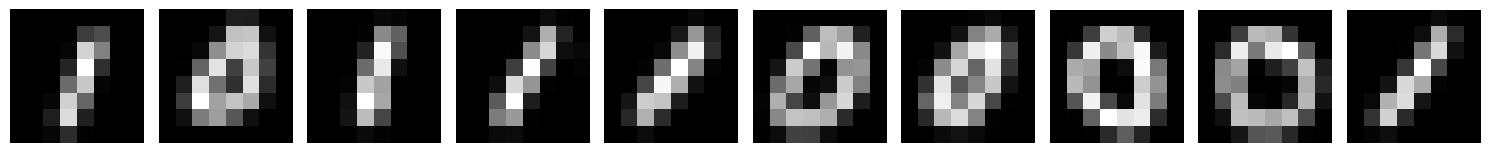

In [8]:
images = images_flat.reshape(-1, 8, 8)
# Plot a few examples
num_examples = 10  # number of examples to display
fig, axes = plt.subplots(1, num_examples, figsize=(15, 2))

for i in range(num_examples):
    # Remove channel dimension if it exists (i.e., converting 8x8x1 to 8x8)
    img = images[i]
    if img.shape[-1] == 1:
        img = img.squeeze(-1)
    
    axes[i].imshow(np.array(img), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Plot samples and marginal distributions

In [11]:
key = jr.PRNGKey(0)

key, subkey = jr.split(key)
t_forward = 1.0
sigma_final = 1.0
samples_t = sample_forward_process(t_forward, n_samples, D=1, sigma_final=sigma_final, samples0=images_flat, key=subkey)

In [12]:
samples_t.shape

(12665, 64)

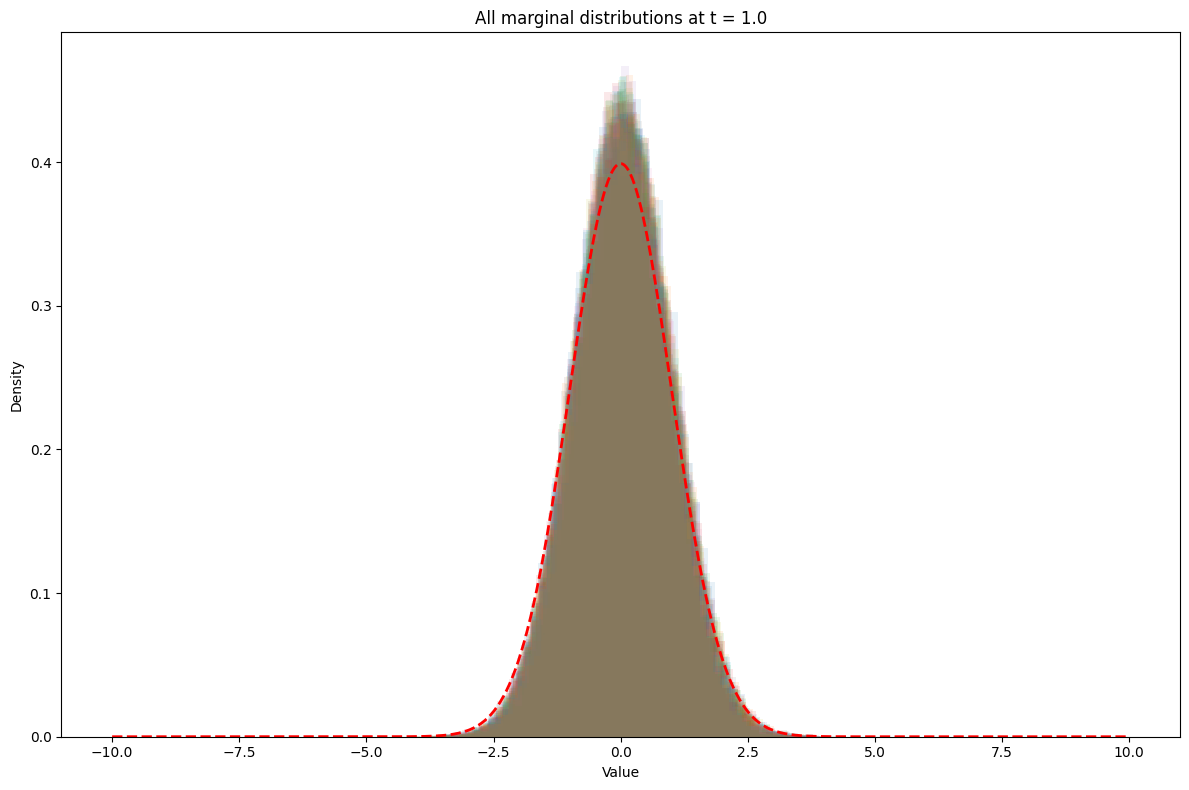

In [13]:
# Create a single plot for all marginal distributions
fig, ax = plt.subplots(figsize=(12, 8))

# Plot histogram for each dimension
for i in range(64):
    ax.hist(samples_t[:, i], bins=50, density=True, alpha=0.1, label=f'Dim {i}')

# Add Gaussian N(0,1) for comparison
x = jnp.linspace(-10, 10, 1000)
gaussian_pdf = (1 / jnp.sqrt(2 * jnp.pi*sigma_final**2)) * jnp.exp(-0.5 * x**2/sigma_final**2)
ax.plot(x, gaussian_pdf, 'r--', linewidth=2, label='Gaussian N(0,1)')

ax.set_title(f'All marginal distributions at t = {t_forward}')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
# ax.legend() # Commenting out as 64 legend entries would be too cluttered

plt.tight_layout()
plt.show()

### Define energy function of duffing oscillator network

In [6]:
def energy_self_oscillator(x, k_lin, k_duff):
    return 1 / 2 * k_lin * x**2 + 1 / 4 * k_duff * x**4

def energy_self_network(x, k_lin, k_duff):
    return jnp.sum(vmap(energy_self_oscillator)(x, k_lin, k_duff))


def energy_coupling_pair(x, y, c_lin, c_optomech):
    return c_lin * x * (x - y) + c_lin * y * (y - x) + c_optomech * (x**2) * y

def energy_coupling_network(x, c_lin, c_optomech, connectivity):
    # get contribution to total energy from each pair of oscillators
    
    def _coupling_energy_pair(x, c_lin, c_optomech, pair):
        # get energy of one pair of oscillators
        i, j = pair
        return energy_coupling_pair(x[i], x[j], c_lin, c_optomech)

    # get energy of all pairs of oscillators
    return jnp.sum(
        vmap(_coupling_energy_pair, in_axes=(None, 0, 0, 0))(
            x, c_lin, c_optomech, connectivity
        )
    )


def _energy_duffing_network(x, k_lin, k_duff, c_lin, c_optomech, connectivity, k_b=1., T=1.):
    # returns energy of network of oscillators given input parameters
    return (
        energy_self_network(x, k_lin, k_duff) +
        energy_coupling_network(x, c_lin, c_optomech, connectivity)
    ) / (k_b * T)

### Define initial parameters

In [15]:
N_osc = 64

k_lin_0 = -1.*jnp.ones(N_osc)
k_duff_0 = jnp.ones(N_osc)
c_lin_0 = jnp.zeros(N_osc)
c_optomech_0 = jnp.zeros(N_osc)
# connectivity = jnp.array([[0, 1]])

args_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0)

flattened_args_initial, unflatten = flatten_util.ravel_pytree(args_initial)


Number of connections: 112
Connectivity matrix shape: (112, 2)

First few connections:
[[ 0  1]
 [ 0  8]
 [ 1  2]
 [ 1  9]
 [ 2  3]
 [ 2 10]
 [ 3  4]
 [ 3 11]
 [ 4  5]
 [ 4 12]
 [ 5  6]
 [ 5 13]
 [ 6  7]
 [ 6 14]
 [ 7 15]
 [ 8  9]
 [ 8 16]
 [ 9 10]
 [ 9 17]
 [10 11]
 [10 18]
 [11 12]
 [11 19]
 [12 13]
 [12 20]
 [13 14]
 [13 21]
 [14 15]
 [14 22]
 [15 23]
 [16 17]
 [16 24]
 [17 18]
 [17 25]
 [18 19]
 [18 26]
 [19 20]
 [19 27]
 [20 21]
 [20 28]
 [21 22]
 [21 29]
 [22 23]
 [22 30]
 [23 31]
 [24 25]
 [24 32]
 [25 26]
 [25 33]
 [26 27]
 [26 34]
 [27 28]
 [27 35]
 [28 29]
 [28 36]
 [29 30]
 [29 37]
 [30 31]
 [30 38]
 [31 39]
 [32 33]
 [32 40]
 [33 34]
 [33 41]
 [34 35]
 [34 42]
 [35 36]
 [35 43]
 [36 37]
 [36 44]
 [37 38]
 [37 45]
 [38 39]
 [38 46]
 [39 47]
 [40 41]
 [40 48]
 [41 42]
 [41 49]
 [42 43]
 [42 50]
 [43 44]
 [43 51]
 [44 45]
 [44 52]
 [45 46]
 [45 53]
 [46 47]
 [46 54]
 [47 55]
 [48 49]
 [48 56]
 [49 50]
 [49 57]
 [50 51]
 [50 58]
 [51 52]
 [51 59]
 [52 53]
 [52 60]
 [53 54]
 [53

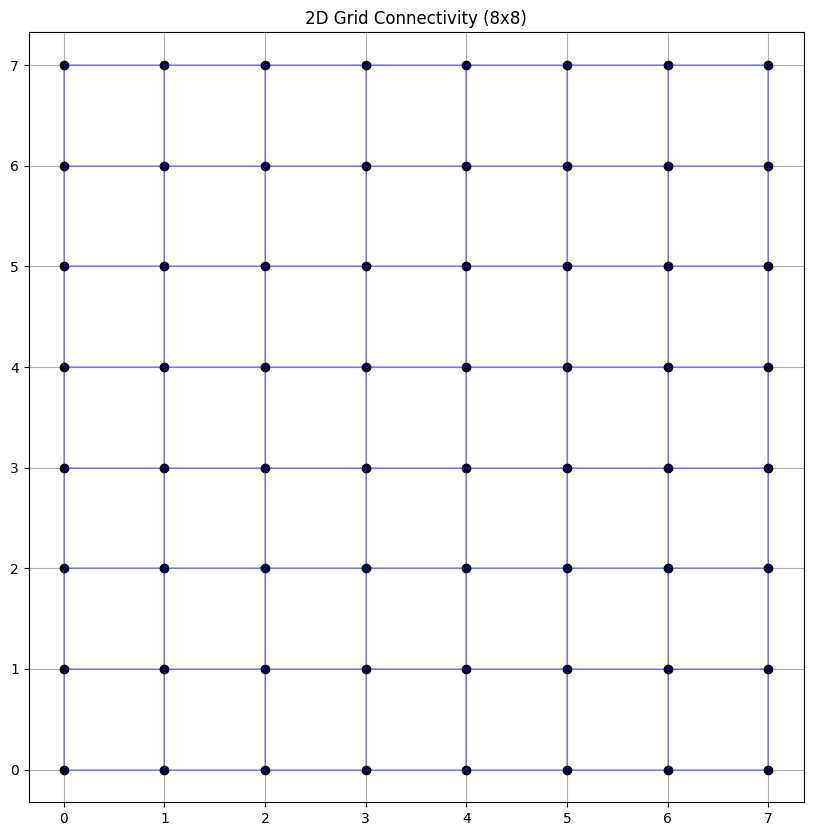

In [22]:
# Create 2D grid connectivity for 8x8 oscillators
def create_2d_grid_connectivity(grid_size=jnp.sqrt(N_osc)):
    connections = []
    
    for i in range(grid_size):
        for j in range(grid_size):
            current = i * grid_size + j
            
            # Connect to right neighbor
            if j < grid_size - 1:
                connections.append([current, current + 1])
            
            # Connect to bottom neighbor
            if i < grid_size - 1:
                connections.append([current, current + grid_size])
    
    return jnp.array(connections)

def visualize_connectivity(connectivity, grid_size=8):
    """
    Visualize the connectivity pattern of the grid.
    
    Args:
        connectivity (jnp.ndarray): Connectivity matrix
        grid_size (int): Size of the square grid
    """
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(10, 10))
    
    # Plot oscillators
    for i in range(grid_size):
        for j in range(grid_size):
            plt.plot(j, i, 'ko')
    
    # Plot connections
    for conn in connectivity:
        i1, j1 = divmod(conn[0], grid_size)
        i2, j2 = divmod(conn[1], grid_size)
        plt.plot([j1, j2], [i1, i2], 'b-', alpha=0.3)
    
    plt.grid(True)
    plt.axis('equal')
    plt.title(f'2D Grid Connectivity ({grid_size}x{grid_size})')
    plt.show()

# Create the connectivity matrix for 8x8 grid
connectivity = create_2d_grid_connectivity(grid_size=8)

# Print the number of connections
print(f"Number of connections: {len(connectivity)}")
print(f"Connectivity matrix shape: {connectivity.shape}")

# Example of first few connections
print("\nFirst few connections:")
print(connectivity)

visualize_connectivity(connectivity)

### Bringe energy into correct form

In [23]:
def energy_duffing_network(x, flattened_args, connectivity):
    k_lin, k_duffing, c_lin, c_optomech = unflatten(flattened_args)
    return _energy_duffing_network(x, k_lin, k_duffing, c_lin, c_optomech, connectivity)
energy_fn = lambda x, flattened_args: energy_duffing_network(x, flattened_args, connectivity)

### Plot initial energy landscape

In [10]:
# Choose training method
training_method = "SM"  # Options: "SM" (Score Matching), "CD1" (Contrastive Divergence), "MLE" (Maximum Likelihood)

# Setup loss and gradient functions based on selected method
if training_method == "SM":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = None
    maximize = False
elif training_method == "CD1":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = lambda flattened_args, batch: -CD1_gradient(energy_fn, batch, flattened_args, dt=0.001, D=1, key=key, num_noise_samples=1000)
    maximize = False
elif training_method == "MLE":
    loss_fn_per_batch = setup_MLE_loss_per_batch(energy_fn)
    gradient_fn_per_batch = setup_MLE_gradient_per_batch(energy_fn)
    maximize = True
else:
    raise ValueError(f"Unknown training method: {training_method}. Choose from 'SM', 'CD1', or 'MLE'.")

In [11]:
# Define filename for saving/loading parameters
n_time_steps = 20
# forward_time_pts = jnp.linspace(0., t_forward, n_time_steps)
forward_time_pts = jnp.exp(jnp.linspace(jnp.log(1e-6), jnp.log(t_forward), n_time_steps))

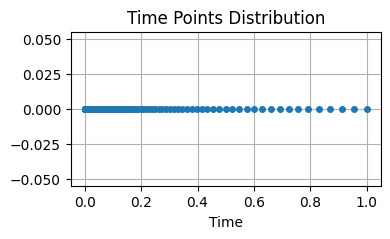

In [ ]:
plt.figure(figsize=(4, 2))
plt.plot(forward_time_pts, jnp.zeros_like(forward_time_pts), 'o', markersize=4)
plt.xlabel('Time')
plt.ylabel('')
plt.title('Time Points Distribution')
plt.grid(True)
plt.show()

Optimization for time 1.0000000000000004e-06 with num epochs: 50000
Epoch 0
params:
[-614.32648671  588.00603632  482.48294911 1459.12532574   81.01413943
    0.        ]
Loss: 2131365.2771
---
Epoch 100
params:
[-604.61168256  578.02371827  492.19630095 1449.14265294   75.8155868
    0.        ]
Loss: 2107669.3243
---
Epoch 200
params:
[-595.69609337  568.09106438  501.11157653 1439.21249692   72.8950573
    0.        ]
Loss: 2048286.8533
---
Epoch 300
params:
[-587.62089836  558.19105597  509.17889743 1429.30732431   67.41370238
    0.        ]
Loss: 1995153.7072
---
Epoch 400
params:
[-580.44575721  548.34844945  516.3438893  1419.46677803   63.60301872
    0.        ]
Loss: 1967590.7144
---
Epoch 500
params:
[-574.16943508  538.55180996  522.60262911 1409.67461094   60.52967148
    0.        ]
Loss: 1947944.9210
---
Epoch 600
params:
[-568.78934564  528.80309069  527.96508916 1399.93301597   58.43949147
    0.        ]
Loss: 1859003.7790
---
Epoch 700
params:
[-564.2353672   519.07

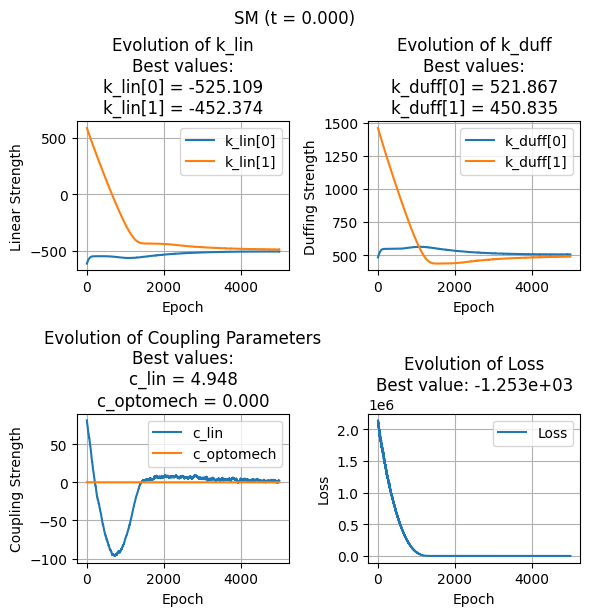

Optimization for time 1.0472898382363598e-06 with num epochs: 3000
Epoch 0
params:
[-525.20946504 -452.47426165  521.76742822  450.7351236     4.847557
    0.        ]
Loss: -985.6825
---
Epoch 100
params:
[-524.73951746 -452.62913614  521.93476802  451.23008357    7.74060332
    0.        ]
Loss: -1022.7475
---
Epoch 200
params:
[-524.21935188 -452.97465248  522.00433396  451.66557096   10.48099858
    0.        ]
Loss: -1101.6269
---
Epoch 300
params:
[-524.13565956 -453.30057427  521.69735626  451.95435122   11.84737157
    0.        ]
Loss: -985.6180
---
Epoch 400
params:
[-523.80862882 -453.48567206  521.56259882  452.41788013   12.6028997
    0.        ]
Loss: -886.7629
---
Epoch 500
params:
[-523.68950777 -453.63592872  521.14956164  452.72446002   12.78093395
    0.        ]
Loss: -918.1527
---
Epoch 600
params:
[-523.50947539 -453.75880624  520.73599362  453.04754354   11.47180629
    0.        ]
Loss: -949.4136
---
Epoch 700
params:
[-523.50418835 -454.38230687  520.20615168 

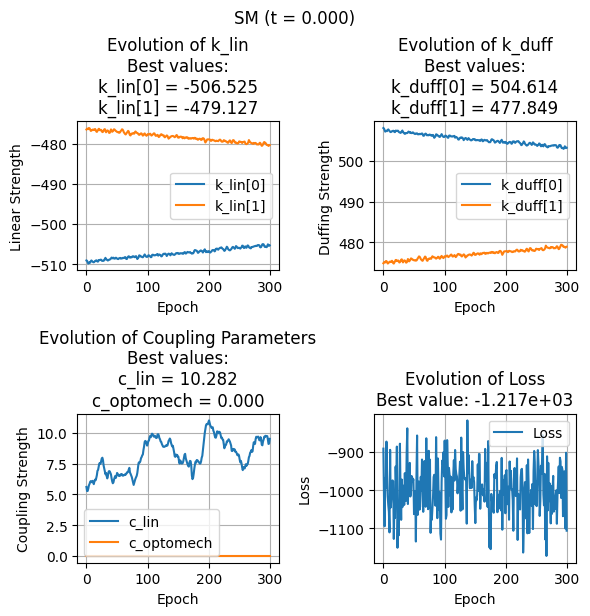

Optimization for time 1.662400978926612e-06 with num epochs: 3000
Epoch 0
params:
[-506.42457584 -479.02686742  504.71397549  477.94928969   10.18229621
    0.        ]
Loss: -955.5954
---
Epoch 100
params:
[-506.64435454 -479.09305725  504.2694721   478.30970949   10.08944574
    0.        ]
Loss: -1028.2321
---
Epoch 200
params:
[-506.43896497 -479.53884839  504.30033536  478.36591916   10.85628996
    0.        ]
Loss: -1172.6837
---
Epoch 300
params:
[-506.06410029 -479.94494433  504.37320067  478.296001      9.72721578
    0.        ]
Loss: -1020.9721
---
Epoch 400
params:
[-505.84986938 -479.6468061   504.36773933  479.03658068   11.17772162
    0.        ]
Loss: -1058.7142
---
Epoch 500
params:
[-506.14849622 -479.5511653   503.87379631  479.44674517   11.07022291
    0.        ]
Loss: -1073.1110
---
Epoch 600
params:
[-506.03171259 -480.09553906  503.73594727  479.13922883    9.92513579
    0.        ]
Loss: -893.7929
---
Epoch 700
params:
[-505.86116117 -480.27594032  503.6667

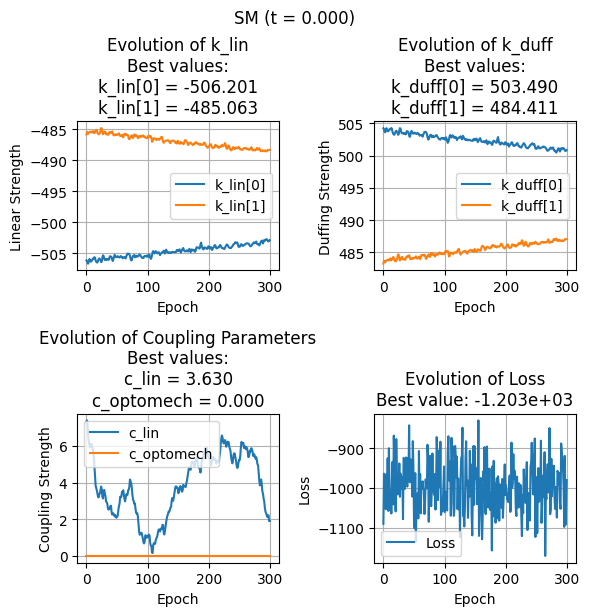

Optimization for time 2.638789104828934e-06 with num epochs: 3000
Epoch 0
params:
[-506.30062219 -485.16340227  503.39035351  484.31059056    3.53028276
    0.        ]
Loss: -861.3637
---
Epoch 100
params:
[-505.84988257 -485.57661832  503.6700029   483.82066267    5.00483021
    0.        ]
Loss: -983.0640
---
Epoch 200
params:
[-505.32632258 -485.3710685   504.04693177  484.07125521    6.30782518
    0.        ]
Loss: -926.8398
---
Epoch 300
params:
[-505.74633212 -485.35654996  503.49710128  484.17589153    6.57915959
    0.        ]
Loss: -950.2968
---
Epoch 400
params:
[-505.47929855 -485.07009662  503.67911458  484.43643845    6.27176706
    0.        ]
Loss: -1009.3022
---
Epoch 500
params:
[-505.54900696 -485.11288698  503.56176765  484.34443048    7.19652776
    0.        ]
Loss: -1048.8951
---
Epoch 600
params:
[-505.62597749 -485.18934023  503.30543504  484.24514256    6.46586432
    0.        ]
Loss: -963.3523
---
Epoch 700
params:
[-505.45319523 -485.59482118  503.2672057

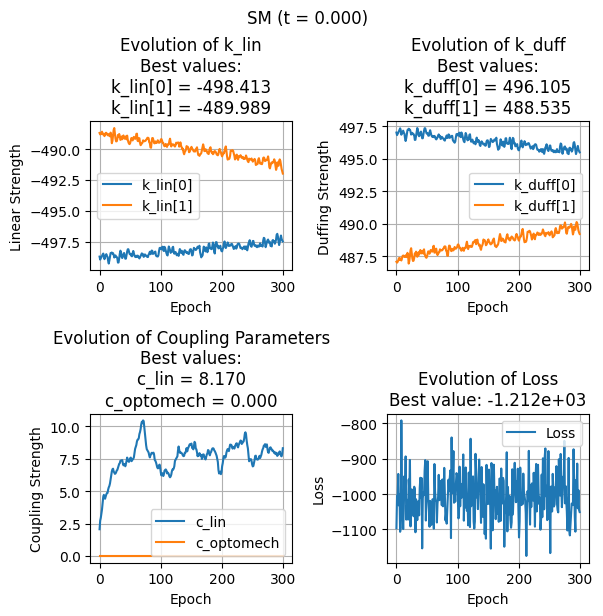

Optimization for time 4.188645235435272e-06 with num epochs: 3000
Epoch 0
params:
[-498.51319763 -489.88910091  496.00542448  488.63456186    8.27021666
    0.        ]
Loss: -1012.8075
---
Epoch 100
params:
[-498.60798862 -490.00997191  496.22378219  488.50567249    8.34812236
    0.        ]
Loss: -1011.1731
---
Epoch 200
params:
[-498.48700919 -490.02100111  496.37626131  488.61215477    7.79735245
    0.        ]
Loss: -1035.3078
---
Epoch 300
params:
[-498.74208084 -490.04940304  496.32232178  488.47535317    5.76863103
    0.        ]
Loss: -1019.1468
---
Epoch 400
params:
[-499.30239232 -490.23322755  495.91819109  488.27421567    7.12216511
    0.        ]
Loss: -1073.1329
---
Epoch 500
params:
[-499.56379139 -489.82200915  495.84413742  488.69067912    6.28436201
    0.        ]
Loss: -930.2074
---
Epoch 600
params:
[-498.77130887 -489.56339331  496.9078012   488.87459653    7.23993069
    0.        ]
Loss: -1006.0827
---
Epoch 700
params:
[-499.24567869 -489.87082912  496.526

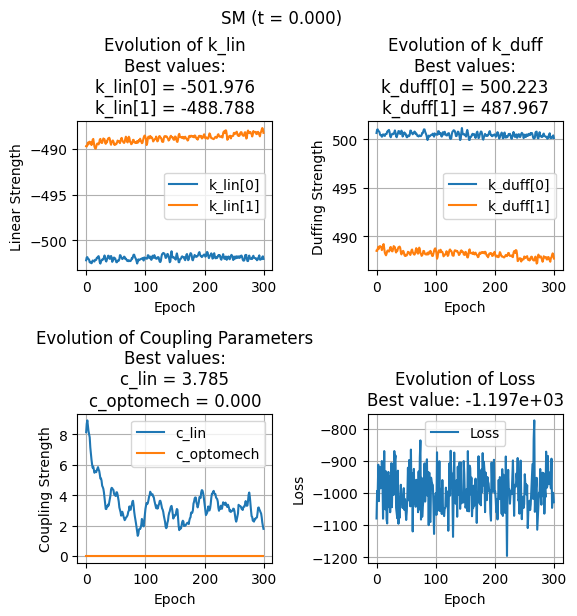

Optimization for time 6.648787838417269e-06 with num epochs: 3000
Epoch 0
params:
[-502.07564803 -488.6877486   500.12310507  488.06748364    3.88502027
    0.        ]
Loss: -1004.9912
---
Epoch 100
params:
[-501.88070815 -489.06493282  500.28074914  487.91376093    5.62896387
    0.        ]
Loss: -1066.5873
---
Epoch 200
params:
[-501.50393578 -488.81416872  500.29403704  488.38260915    5.83058314
    0.        ]
Loss: -952.5051
---
Epoch 300
params:
[-501.4429344  -488.94551283  500.0944404   488.39977444    6.51760561
    0.        ]
Loss: -989.5346
---
Epoch 400
params:
[-501.40551407 -489.17585456  499.77492496  488.22965638    6.20757748
    0.        ]
Loss: -974.5919
---
Epoch 500
params:
[-501.26869823 -489.26466099  499.72401452  488.20746274    6.4949904
    0.        ]
Loss: -941.8069
---
Epoch 600
params:
[-500.52494933 -489.32140376  500.23182892  488.2779819     6.59472541
    0.        ]
Loss: -948.3747
---
Epoch 700
params:
[-500.89144826 -489.22773707  499.71265891

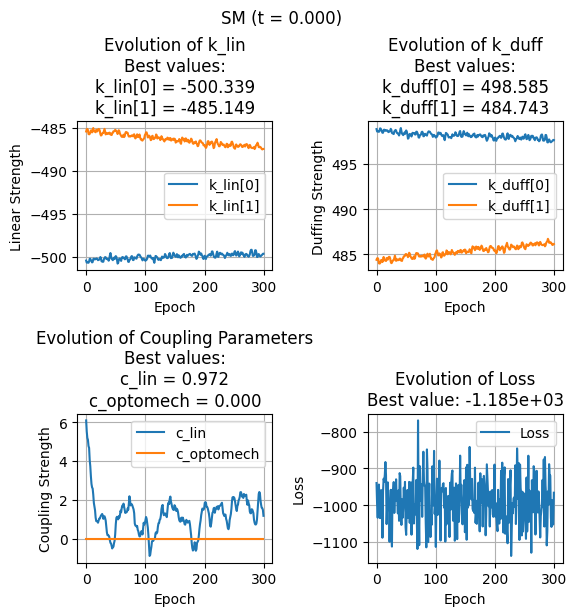

Optimization for time 1.0553861030365246e-05 with num epochs: 3000
Epoch 0
params:
[-500.43878894 -485.04912065  498.4850726   484.64255413    0.87168305
    0.        ]
Loss: -848.2955
---
Epoch 100
params:
[-500.28265085 -485.54155834  498.57780816  484.35700751    3.54902683
    0.        ]
Loss: -1005.2468
---
Epoch 200
params:
[-500.04852261 -485.64345597  498.7426505   484.30406114    4.89797026
    0.        ]
Loss: -930.0042
---
Epoch 300
params:
[-499.61094466 -485.2405384   498.88886578  484.73188415    5.29527861
    0.        ]
Loss: -981.3153
---
Epoch 400
params:
[-499.80285602 -485.34196813  498.55716043  484.73638792    5.27415667
    0.        ]
Loss: -1035.1839
---
Epoch 500
params:
[-499.76552406 -485.63717548  498.46403138  484.5675732     7.12525674
    0.        ]
Loss: -901.7709
---
Epoch 600
params:
[-499.90966086 -485.38448499  498.16733155  484.99480828    7.18928054
    0.        ]
Loss: -968.3845
---
Epoch 700
params:
[-499.42375793 -485.89342817  498.560338

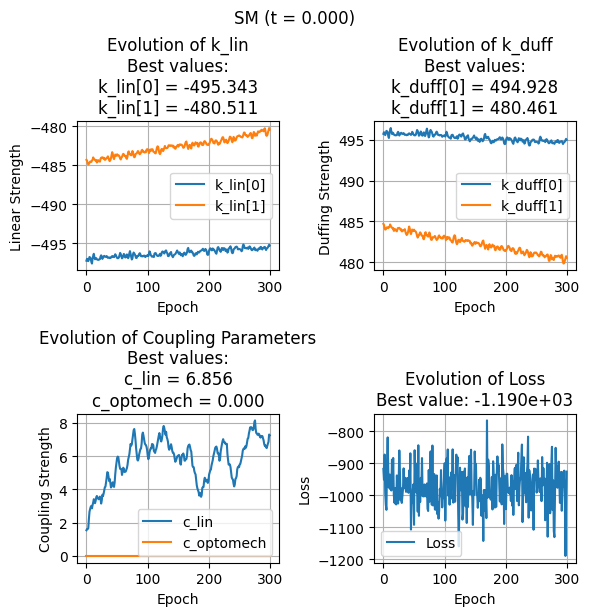

Optimization for time 1.6752524724082142e-05 with num epochs: 3000
Epoch 0
params:
[-495.24349467 -480.41053499  495.02753879  480.56106065    6.95621032
    0.        ]
Loss: -1053.0376
---
Epoch 100
params:
[-495.60897449 -480.34482841  494.67495267  480.75691852    6.04022017
    0.        ]
Loss: -924.7969
---
Epoch 200
params:
[-495.64672934 -480.46411651  494.56918526  480.73949901    6.61219016
    0.        ]
Loss: -846.7618
---
Epoch 300
params:
[-495.53276578 -480.60267802  494.60533614  480.77658805    6.97465743
    0.        ]
Loss: -1026.1321
---
Epoch 400
params:
[-495.21631984 -480.6302755   494.94232276  480.91033707    6.76488054
    0.        ]
Loss: -924.4647
---
Epoch 500
params:
[-495.22466459 -480.75862891  494.96825032  480.84698211    6.3761897
    0.        ]
Loss: -1026.8657
---
Epoch 600
params:
[-495.50111409 -480.81302585  494.55998237  480.87940429    5.22190646
    0.        ]
Loss: -1058.2373
---
Epoch 700
params:
[-495.18076824 -480.78747164  494.77339

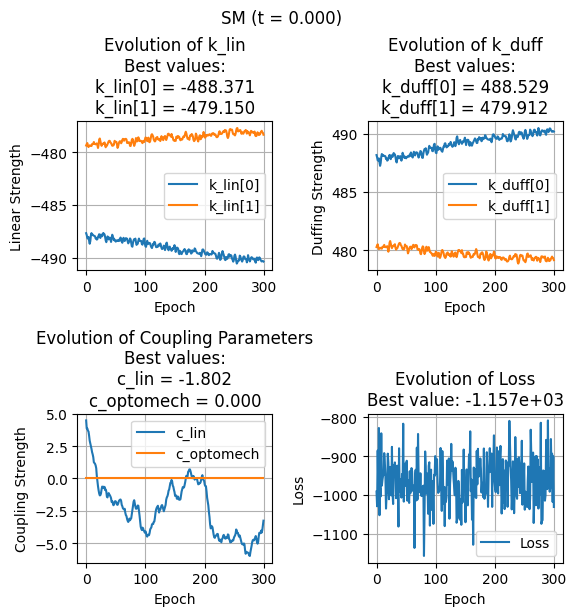

Optimization for time 2.6591887445126937e-05 with num epochs: 3000
Epoch 0
params:
[-488.47111261 -479.24971388  488.42946977  479.81188117   -1.70223774
    0.        ]
Loss: -1042.1784
---
Epoch 100
params:
[-487.86043682 -478.99629978  489.27254523  480.01533148    2.23397561
    0.        ]
Loss: -1074.6023
---
Epoch 200
params:
[-487.96854594 -478.98205566  489.43425234  479.83041102    5.09173817
    0.        ]
Loss: -1104.5574
---
Epoch 300
params:
[-488.52524622 -478.12600427  489.24180129  480.3416433     5.92683394
    0.        ]
Loss: -1072.3661
---
Epoch 400
params:
[-488.43464222 -478.38157736  489.63033587  479.76651395    7.74563089
    0.        ]
Loss: -1029.5865
---
Epoch 500
params:
[-488.59951702 -478.33131812  489.58351612  479.53396105    7.54290596
    0.        ]
Loss: -1056.1380
---
Epoch 600
params:
[-488.95626434 -478.29589893  489.47705834  479.36076008    9.16659104
    0.        ]
Loss: -1085.1477
---
Epoch 700
params:
[-488.42522157 -478.07771059  490.1

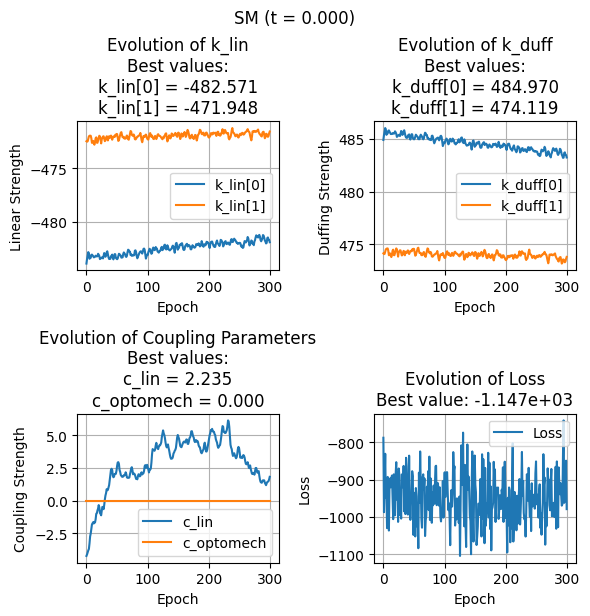

Optimization for time 4.221026320156901e-05 with num epochs: 3000
Epoch 0
params:
[-482.47078983 -471.84845327  485.07035847  474.21884802    2.1349509
    0.        ]
Loss: -921.3251
---
Epoch 100
params:
[-4.82715133e+02 -4.71533045e+02  4.84561005e+02  4.74194691e+02
 -1.96754335e-01  0.00000000e+00]
Loss: -924.5551
---
Epoch 200
params:
[-482.52062101 -471.34462521  484.54249008  473.89578612   -2.57561962
    0.        ]
Loss: -882.1001
---
Epoch 300
params:
[-482.16064437 -471.4605977   484.83367495  473.48827514   -4.32869411
    0.        ]
Loss: -979.2197
---
Epoch 400
params:
[-482.27389026 -471.08884902  484.61532121  473.66878919   -4.00344487
    0.        ]
Loss: -908.0932
---
Epoch 500
params:
[-482.13972861 -471.21583059  484.51230989  473.30744973   -4.79930763
    0.        ]
Loss: -981.5664
---
Epoch 600
params:
[-482.1248674  -470.92377563  484.38095188  473.32824727   -4.71698198
    0.        ]
Loss: -892.4613
---
Epoch 700
params:
[-482.32196448 -470.78177187  48

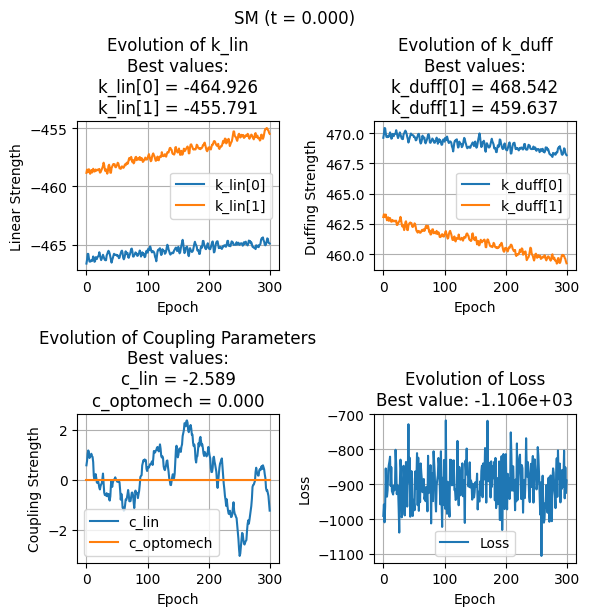

Optimization for time 6.700187503509591e-05 with num epochs: 3000
Epoch 0
params:
[-465.02588487 -455.8910082   468.44226155  459.53706681   -2.68869329
    0.        ]
Loss: -844.8004
---
Epoch 100
params:
[-464.67151025 -455.4334625   468.60549536  459.72554459   -3.1812978
    0.        ]
Loss: -928.7720
---
Epoch 200
params:
[-464.45340241 -455.45688268  468.70796359  459.38784534   -2.74048558
    0.        ]
Loss: -851.5670
---
Epoch 300
params:
[-464.47653983 -455.18690114  468.46029062  459.33216017   -2.1972386
    0.        ]
Loss: -981.7689
---
Epoch 400
params:
[-4.64366929e+02 -4.54873698e+02  4.68579223e+02  4.59408426e+02
 -3.86183262e-01  0.00000000e+00]
Loss: -1019.7954
---
Epoch 500
params:
[-464.53845884 -455.14949849  468.09397696  458.72693414   -2.44543508
    0.        ]
Loss: -970.7405
---
Epoch 600
params:
[-464.2854375  -454.74697265  468.20569711  458.92595842   -1.50805342
    0.        ]
Loss: -892.5882
---
Epoch 700
params:
[-463.67976756 -454.97261358  46

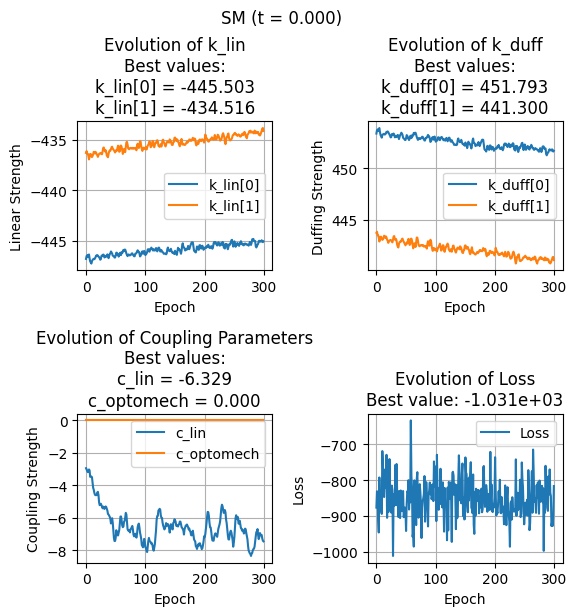

Optimization for time 0.0001063544957486012 with num epochs: 3000
Epoch 0
params:
[-445.60331174 -434.41612046  451.69341415  441.39959438   -6.42885901
    0.        ]
Loss: -894.4965
---
Epoch 100
params:
[-444.49153286 -433.86701588  452.54940329  441.59955299   -4.76705485
    0.        ]
Loss: -881.8590
---
Epoch 200
params:
[-444.49769318 -433.67309012  452.09843902  441.49577596   -5.20626461
    0.        ]
Loss: -838.2003
---
Epoch 300
params:
[-444.35357553 -433.60899504  451.79927898  441.33267793   -5.04930295
    0.        ]
Loss: -837.7559
---
Epoch 400
params:
[-444.37704132 -433.42819026  451.4453302   441.20435473   -4.32346828
    0.        ]
Loss: -855.8270
---
Epoch 500
params:
[-444.50096265 -433.08517013  451.0938037   441.26454152   -3.12811929
    0.        ]
Loss: -893.6447
---
Epoch 600
params:
[-443.73709337 -432.99272513  451.42266348  441.21442506   -3.30996307
    0.        ]
Loss: -738.9987
---
Epoch 700
params:
[-443.65071135 -432.81615922  451.01518583 

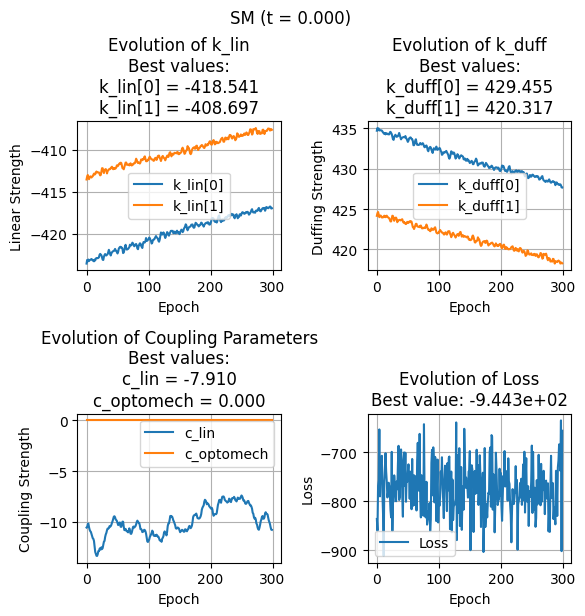

Optimization for time 0.00016882033167003622 with num epochs: 3000
Epoch 0
params:
[-418.64109163 -408.79687554  429.35548104  420.21723858   -8.01000774
    0.        ]
Loss: -753.2564
---
Epoch 100
params:
[-418.02025519 -408.47420256  429.53844414  420.19206004  -10.61452089
    0.        ]
Loss: -848.0217
---
Epoch 200
params:
[-417.46546779 -408.18058927  429.66709934  420.45056895  -11.89062608
    0.        ]
Loss: -701.3754
---
Epoch 300
params:
[-417.29324687 -408.26943731  429.39662653  420.21866376  -12.11121145
    0.        ]
Loss: -913.6274
---
Epoch 400
params:
[-417.2941768  -407.90607157  429.26340878  420.47761962   -9.94646018
    0.        ]
Loss: -807.8062
---
Epoch 500
params:
[-417.51255239 -408.07223545  428.6703955   420.16490837  -10.07496499
    0.        ]
Loss: -743.7797
---
Epoch 600
params:
[-416.87698792 -408.06143743  428.76356883  420.08085749  -11.29559611
    0.        ]
Loss: -756.2362
---
Epoch 700
params:
[-416.46895725 -407.96587785  428.89959833

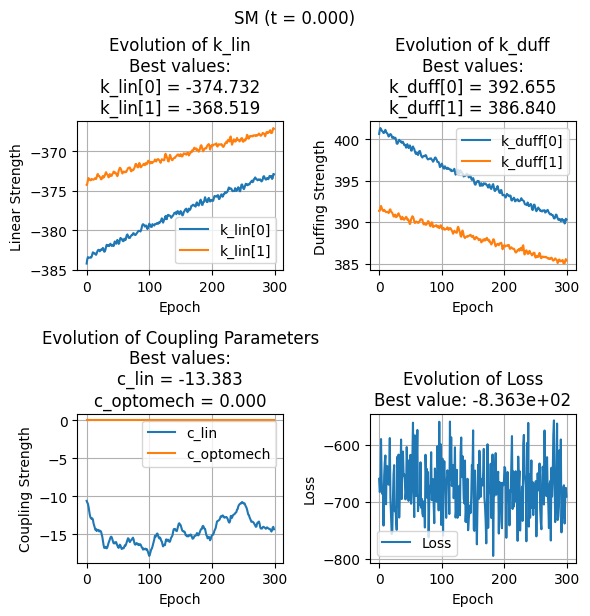

Optimization for time 0.000267974608732569 with num epochs: 3000
Epoch 0
params:
[-374.83178315 -368.41863926  392.55503348  386.94048854  -13.48271876
    0.        ]
Loss: -669.6984
---
Epoch 100
params:
[-374.57776079 -367.97536456  392.41341916  386.88042314   -9.80002001
    0.        ]
Loss: -650.0213
---
Epoch 200
params:
[-374.07892184 -368.02039818  392.3019857   386.18011873   -9.12344335
    0.        ]
Loss: -734.4729
---
Epoch 300
params:
[-374.13745552 -367.73141899  391.80733839  385.97788333   -7.89171521
    0.        ]
Loss: -790.6596
---
Epoch 400
params:
[-373.53161125 -367.20555218  391.8332349   385.94881311   -7.80561466
    0.        ]
Loss: -632.9021
---
Epoch 500
params:
[-372.98982869 -366.95667258  392.0988333   385.64602525   -5.99199748
    0.        ]
Loss: -615.2464
---
Epoch 600
params:
[-372.96673423 -366.79778228  391.60289818  385.08923359   -6.80154892
    0.        ]
Loss: -687.7874
---
Epoch 700
params:
[-372.92494651 -366.41710255  391.12577325  

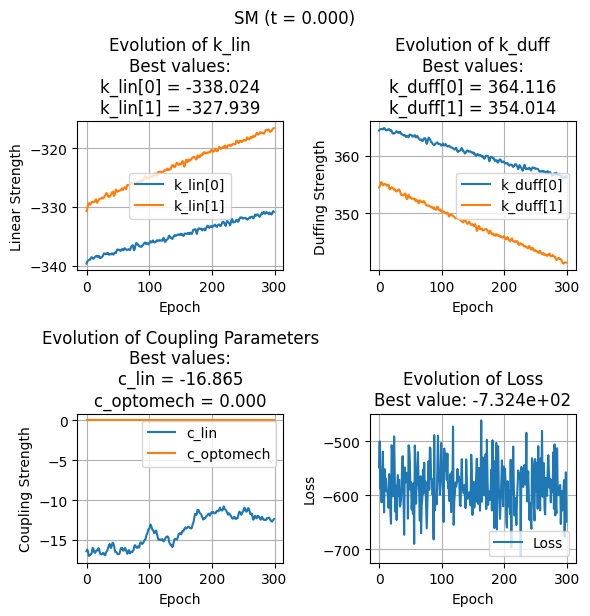

Optimization for time 0.00042536577327503903 with num epochs: 3000
Epoch 0
params:
[-338.12439964 -327.83874737  364.01632514  354.11438652  -16.96546028
    0.        ]
Loss: -592.8677
---
Epoch 100
params:
[-337.14220266 -327.35031719  363.80884823  353.86235854  -19.13115266
    0.        ]
Loss: -565.9992
---
Epoch 200
params:
[-336.86604299 -326.71054481  363.12979099  353.93435773  -19.35762715
    0.        ]
Loss: -563.2099
---
Epoch 300
params:
[-336.5413184  -326.77533181  362.44570997  353.11885919  -19.75315753
    0.        ]
Loss: -610.8112
---
Epoch 400
params:
[-335.74647081 -326.16275401  362.06884067  353.04076732  -20.16191116
    0.        ]
Loss: -589.5598
---
Epoch 500
params:
[-335.53864372 -325.3390073   361.37181324  353.25219155  -19.88368805
    0.        ]
Loss: -561.6124
---
Epoch 600
params:
[-334.86573772 -325.80623686  361.06664642  352.16873955  -18.93359919
    0.        ]
Loss: -574.0459
---
Epoch 700
params:
[-334.21759641 -325.12396096  360.69059021

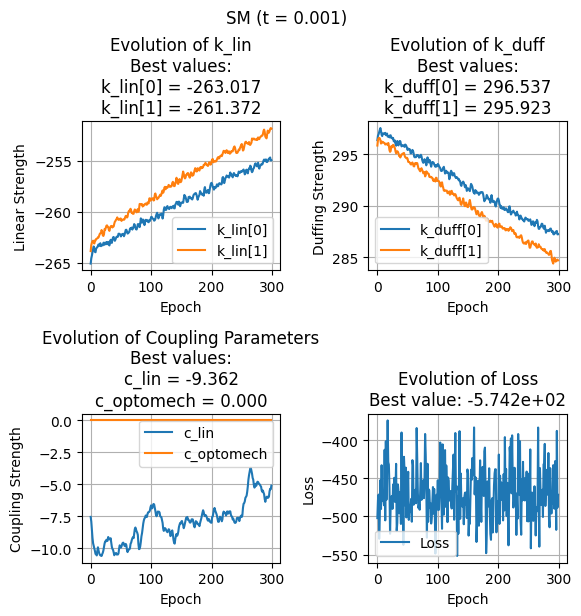

Optimization for time 0.0006751984523072504 with num epochs: 3000
Epoch 0
params:
[-262.91670732 -261.47242762  296.63694286  295.82328259   -9.26230702
    0.        ]
Loss: -473.1567
---
Epoch 100
params:
[-261.4006958  -259.9142785   297.64876688  295.70272088   -9.60457947
    0.        ]
Loss: -414.8259
---
Epoch 200
params:
[-261.37426256 -259.62330764  297.03117985  294.53234474  -10.48381588
    0.        ]
Loss: -447.2161
---
Epoch 300
params:
[-260.98436768 -258.58825748  296.57230409  294.46731233  -10.1971312
    0.        ]
Loss: -467.4561
---
Epoch 400
params:
[-260.5927593  -258.60659931  296.13263863  293.38578045  -10.63651813
    0.        ]
Loss: -397.6870
---
Epoch 500
params:
[-260.30231188 -257.60585167  295.73081084  293.3898421   -10.3144487
    0.        ]
Loss: -475.2115
---
Epoch 600
params:
[-260.23388001 -257.44060892  295.1530697   292.34654521  -10.64554015
    0.        ]
Loss: -531.9702
---
Epoch 700
params:
[-259.5507483  -257.20945712  295.39449028  2

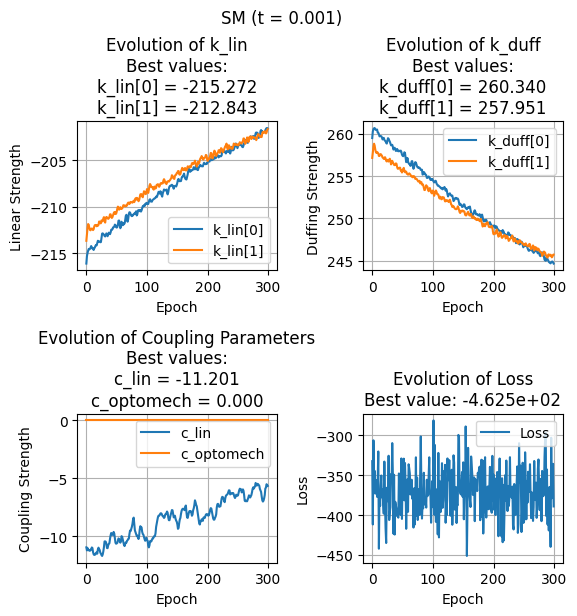

Optimization for time 0.0010717668854455034 with num epochs: 3000
Epoch 0
params:
[-215.17228922 -212.74348069  260.43986563  258.05090245  -11.30104137
    0.        ]
Loss: -327.6821
---
Epoch 100
params:
[-213.66781367 -211.1339179   260.97618324  258.66471058  -10.65816892
    0.        ]
Loss: -322.8372
---
Epoch 200
params:
[-212.75199291 -210.35471385  260.50857748  257.77887074  -11.9262389
    0.        ]
Loss: -337.9102
---
Epoch 300
params:
[-212.25287817 -210.12798937  259.74664763  256.94182713  -10.64315409
    0.        ]
Loss: -377.9308
---
Epoch 400
params:
[-211.84252483 -209.38255501  259.02583467  256.19212966   -9.73678991
    0.        ]
Loss: -404.9432
---
Epoch 500
params:
[-211.55088076 -208.92131487  257.91857396  255.35144248  -10.04309639
    0.        ]
Loss: -388.7156
---
Epoch 600
params:
[-210.444859   -207.92661174  257.8541378   254.96762972  -10.30802943
    0.        ]
Loss: -384.8765
---
Epoch 700
params:
[-210.05652231 -207.71557301  257.14931308  

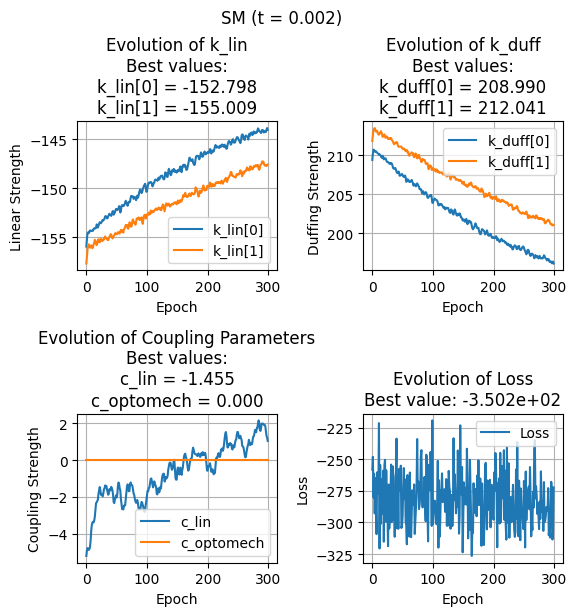

Optimization for time 0.0017012542798525887 with num epochs: 3000
Epoch 0
params:
[-152.69813174 -154.90895334  209.09036887  212.14097498   -1.55503609
    0.        ]
Loss: -295.6787
---
Epoch 100
params:
[-151.62039766 -153.93682749  209.25861175  211.82074426   -4.2938532
    0.        ]
Loss: -292.8395
---
Epoch 200
params:
[-151.02587384 -153.16422384  209.04168118  211.62608995   -3.72588458
    0.        ]
Loss: -264.1305
---
Epoch 300
params:
[-150.8405106  -152.41665477  208.34054428  211.29513519   -3.93292731
    0.        ]
Loss: -283.4722
---
Epoch 400
params:
[-150.38218619 -152.17097312  207.88064166  210.49802546   -3.98311932
    0.        ]
Loss: -239.0982
---
Epoch 500
params:
[-150.25882805 -151.8931354   207.3205071   209.71978413   -3.24079048
    0.        ]
Loss: -283.9370
---
Epoch 600
params:
[-149.40525719 -151.49156054  207.10794408  209.12665811   -3.73226295
    0.        ]
Loss: -320.4461
---
Epoch 700
params:
[-149.61782645 -150.86258077  206.4716735   

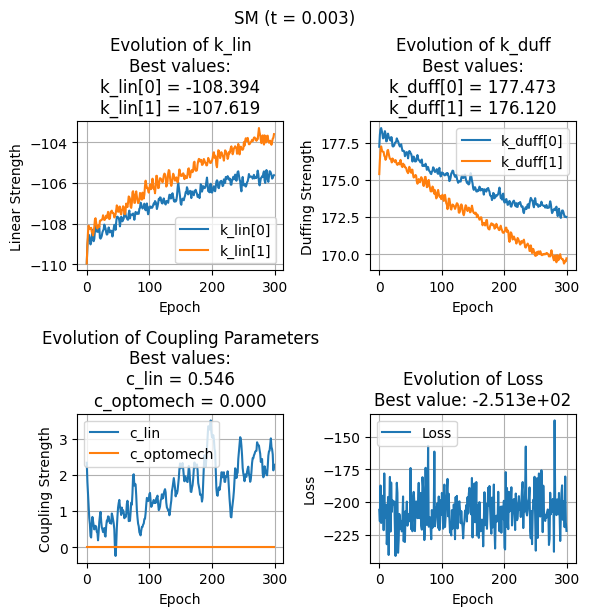

Optimization for time 0.002700462352420683 with num epochs: 3000
Epoch 0
params:
[-108.29379454 -107.51873534  177.57257102  176.22006281    0.44640402
    0.        ]
Loss: -201.3599
---
Epoch 100
params:
[-106.46077628 -105.65913345  178.97933448  177.54390549    1.67633136
    0.        ]
Loss: -177.2702
---
Epoch 200
params:
[-106.31296501 -105.71150068  178.65052378  176.99238985    0.9521909
    0.        ]
Loss: -211.0844
---
Epoch 300
params:
[-106.30198867 -105.8782619   177.94255019  176.11638544    0.19070988
    0.        ]
Loss: -192.7065
---
Epoch 400
params:
[-105.79476973 -105.29155464  177.72312095  176.1914479     0.39694957
    0.        ]
Loss: -204.2278
---
Epoch 500
params:
[-105.5607269  -105.23427386  177.4217305   175.87835256    0.62002678
    0.        ]
Loss: -225.8283
---
Epoch 600
params:
[-105.59649346 -104.72436361  177.34661469  175.70519159    1.60444846
    0.        ]
Loss: -217.8018
---
Epoch 700
params:
[-105.72744958 -104.64369838  177.13763279  1

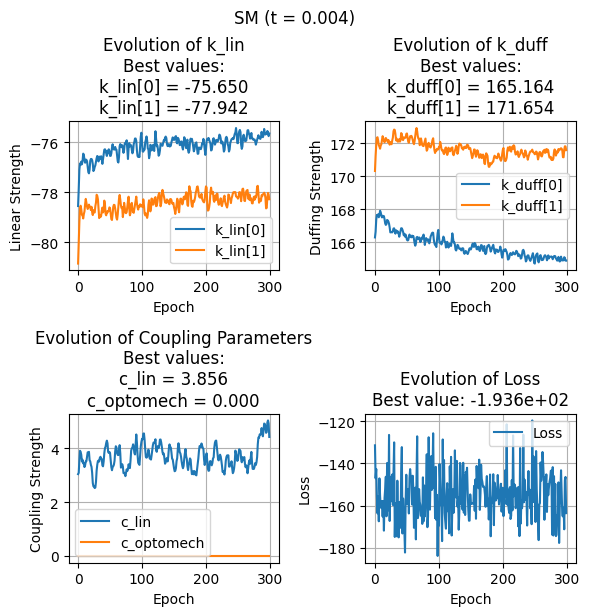

Optimization for time 0.004286541408420925 with num epochs: 3000
Epoch 0
params:
[-75.5497822  -77.84158888 165.26404091 171.75362293   3.95608817
   0.        ]
Loss: -160.0893
---
Epoch 100
params:
[-73.98296525 -76.72733968 166.78848018 171.99321016   4.15675653
   0.        ]
Loss: -145.2467
---
Epoch 200
params:
[-73.81134084 -76.29567422 166.67956958 172.0002055    3.95494843
   0.        ]
Loss: -147.5906
---
Epoch 300
params:
[-73.52603945 -76.28594779 167.23601708 171.42079715   4.66108979
   0.        ]
Loss: -147.8216
---
Epoch 400
params:
[-73.7007039  -76.13159836 167.33390112 171.07802017   4.56496388
   0.        ]
Loss: -140.4067
---
Epoch 500
params:
[-74.02593672 -76.35648342 166.85977608 170.77628759   4.10652654
   0.        ]
Loss: -156.4129
---
Epoch 600
params:
[-73.68182567 -76.2311955  167.1295923  170.77918864   4.18869136
   0.        ]
Loss: -161.7070
---
Epoch 700
params:
[-73.57188625 -76.29045592 167.07367148 170.3615366    4.54015725
   0.        ]
Loss:

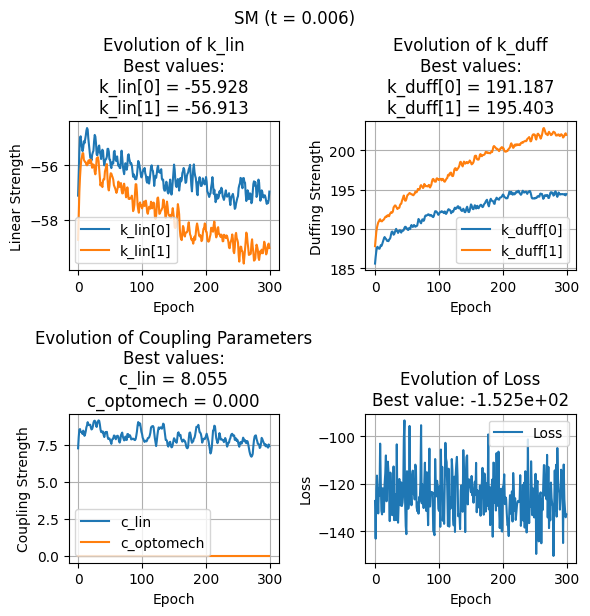

Optimization for time 0.006804181968927099 with num epochs: 3000
Epoch 0
params:
[-55.82818324 -56.81266526 191.2870273  195.5034361    8.1546055
   0.        ]
Loss: -122.5094
---
Epoch 100
params:
[-53.80536119 -54.85044011 193.28951144 198.02382168   7.79353547
   0.        ]
Loss: -136.5436
---
Epoch 200
params:
[-54.26332683 -54.45988029 194.15967562 199.1602955    8.84841911
   0.        ]
Loss: -130.0688
---
Epoch 300
params:
[-54.3713417  -54.70464396 194.58547706 199.20895302   7.62862635
   0.        ]
Loss: -128.6970
---
Epoch 400
params:
[-54.51053238 -54.93253405 195.23316604 199.87474332   7.9941132
   0.        ]
Loss: -134.6175
---
Epoch 500
params:
[-54.44116218 -54.88212874 195.32699336 200.75766226   8.19203732
   0.        ]
Loss: -106.7048
---
Epoch 600
params:
[-54.43917752 -55.29566622 195.58168785 200.67067663   7.87336184
   0.        ]
Loss: -114.9727
---
Epoch 700
params:
[-54.36036036 -55.28913606 196.21121588 201.29156655   7.59232161
   0.        ]
Loss: -

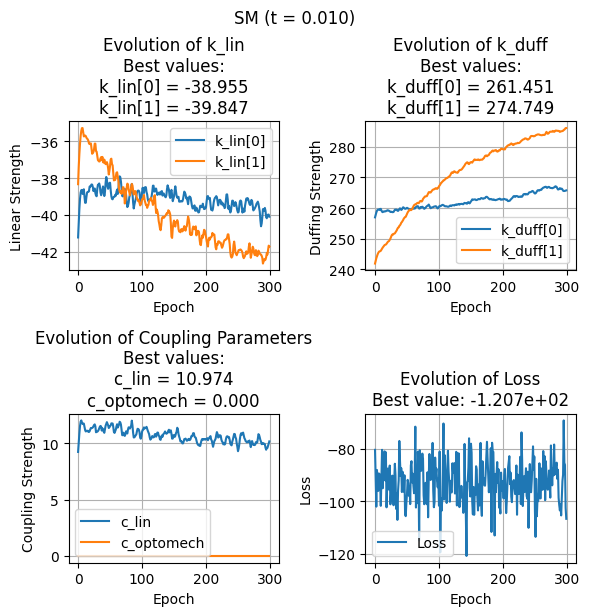

Optimization for time 0.010800523745162532 with num epochs: 3000
Epoch 0
params:
[-38.85457181 -39.74735105 261.55088934 274.84917114  11.07444892
   0.        ]
Loss: -88.0303
---
Epoch 100
params:
[-35.06170142 -37.71290758 265.54009389 276.02612381  11.84879363
   0.        ]
Loss: -71.4363
---
Epoch 200
params:
[-35.79265859 -37.50555975 266.75903102 275.80200929  11.53927582
   0.        ]
Loss: -95.5405
---
Epoch 300
params:
[-36.14391222 -37.60168431 267.9576498  275.575435    11.41059045
   0.        ]
Loss: -84.4802
---
Epoch 400
params:
[-36.18569559 -37.32539731 269.91522635 275.68021462  11.17654566
   0.        ]
Loss: -76.7721
---
Epoch 500
params:
[-36.834154   -37.06859133 269.72336353 276.70900731  11.59481124
   0.        ]
Loss: -97.7740
---
Epoch 600
params:
[-36.48044944 -37.23323556 271.26806608 275.82101138  11.7865603
   0.        ]
Loss: -84.3951
---
Epoch 700
params:
[-36.83429046 -37.59143268 272.10921773 275.45962897  11.15867616
   0.        ]
Loss: -84.907

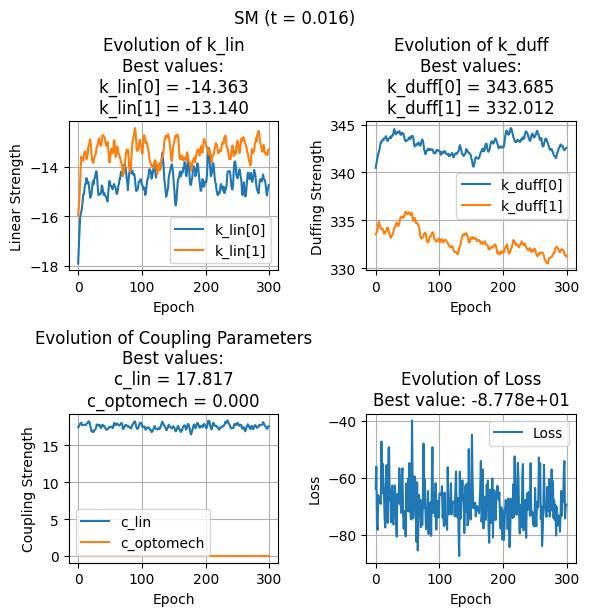

Optimization for time 0.017144061358519702 with num epochs: 3000
Epoch 0
params:
[-14.26258912 -13.04025146 343.78538022 332.11163138  17.91718402
   0.        ]
Loss: -70.6565
---
Epoch 100
params:
[-10.24503917 -10.36717758 347.18119298 334.95517941  17.98689306
   0.        ]
Loss: -68.6781
---
Epoch 200
params:
[-10.66820612 -10.42751478 347.29367469 335.96946124  17.05964885
   0.        ]
Loss: -74.0562
---
Epoch 300
params:
[-10.43683377  -9.66442943 347.15309276 337.88930381  17.91370067
   0.        ]
Loss: -69.5431
---
Epoch 400
params:
[-10.3695199   -9.59209317 347.99373345 339.11488966  17.60944506
   0.        ]
Loss: -76.4573
---
Epoch 500
params:
[-10.43276734 -10.50476175 348.75419636 339.37484164  17.28631801
   0.        ]
Loss: -76.0592
---
Epoch 600
params:
[-10.62042299 -10.55443121 349.56631631 340.7536859   17.18789171
   0.        ]
Loss: -73.4061
---
Epoch 700
params:
[-10.62261591 -10.49966657 350.480484   341.18445912  17.59351763
   0.        ]
Loss: -76.35

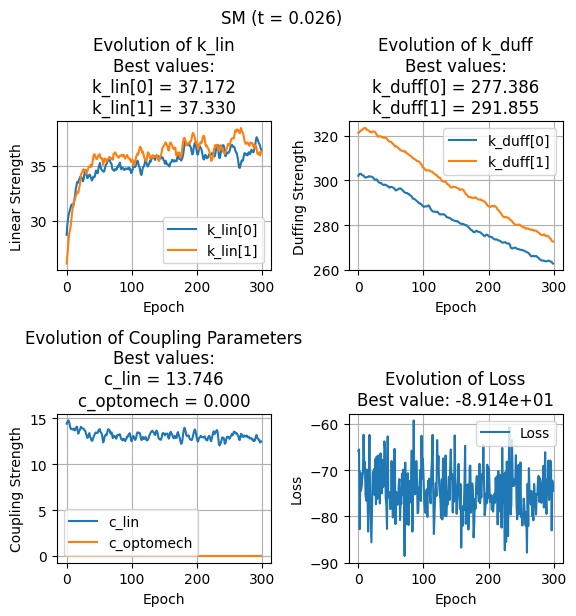

Optimization for time 0.027213387683753087 with num epochs: 3000
Epoch 0
params:
[ 37.2718607   37.23026252 277.48575994 291.75461303  13.64626133
   0.        ]
Loss: -73.7192
---
Epoch 100
params:
[ 39.76884849  40.33995088 277.68690326 290.72964686  11.66625416
   0.        ]
Loss: -73.0650
---
Epoch 200
params:
[ 42.07532841  41.26658615 275.74211565 287.27107443  11.30831394
   0.        ]
Loss: -70.9355
---
Epoch 300
params:
[ 42.47001005  42.35356337 274.06397275 284.06472503  11.42251065
   0.        ]
Loss: -72.9149
---
Epoch 400
params:
[ 41.72529919  42.81163473 269.661774   282.2890116   11.18281754
   0.        ]
Loss: -77.0430
---
Epoch 500
params:
[ 43.07468191  42.81378675 269.01830226 278.39434802  11.27222609
   0.        ]
Loss: -76.8733
---
Epoch 600
params:
[ 42.20661545  43.90642775 265.65417546 276.5613476   10.96378647
   0.        ]
Loss: -72.5305
---
Epoch 700
params:
[ 42.98880072  44.11313203 264.68840651 274.29450761  11.9103706
   0.        ]
Loss: -83.926

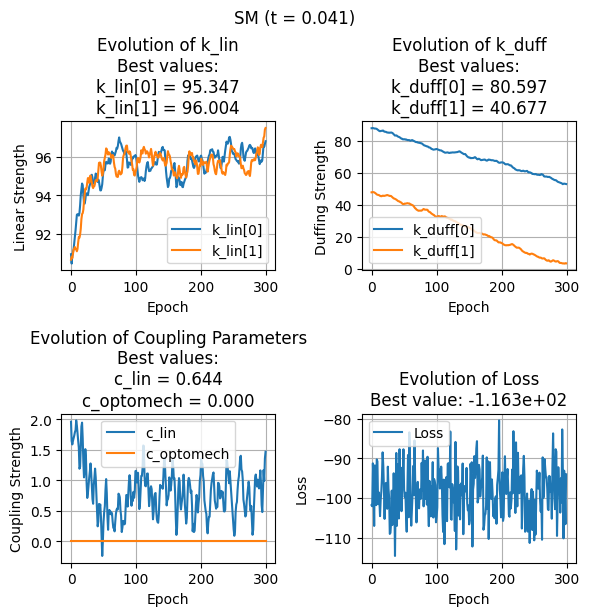

Optimization for time 0.043196792973341724 with num epochs: 3000
Epoch 0
params:
[95.44704143 95.90369483 80.69714394 40.57696712  0.54370864  0.        ]
Loss: -96.6672
---
Epoch 100
params:
[95.07672035 96.07563087 76.28697834 39.54399611  0.90930689  0.        ]
Loss: -95.4438
---
Epoch 200
params:
[94.86389636 97.43915421 73.20117907 38.36755921  0.54793211  0.        ]
Loss: -86.6312
---
Epoch 300
params:
[ 9.60778844e+01  9.64590370e+01  7.12041414e+01  3.55893653e+01
 -5.43393462e-02  0.00000000e+00]
Loss: -100.5642
---
Epoch 400
params:
[95.64286357 96.52675758 67.32390978 34.09413116  0.15241953  0.        ]
Loss: -101.5197
---
Epoch 500
params:
[ 9.46622534e+01  9.70197435e+01  6.27125645e+01  3.24362320e+01
 -1.34469392e-02  0.00000000e+00]
Loss: -92.0971
---
Epoch 600
params:
[96.08527531 96.36564117 61.34024708 29.5858461   0.58591045  0.        ]
Loss: -93.0830
---
Epoch 700
params:
[96.81839084 96.07293177 59.54122448 27.24822533  0.44540575  0.        ]
Loss: -104.9573


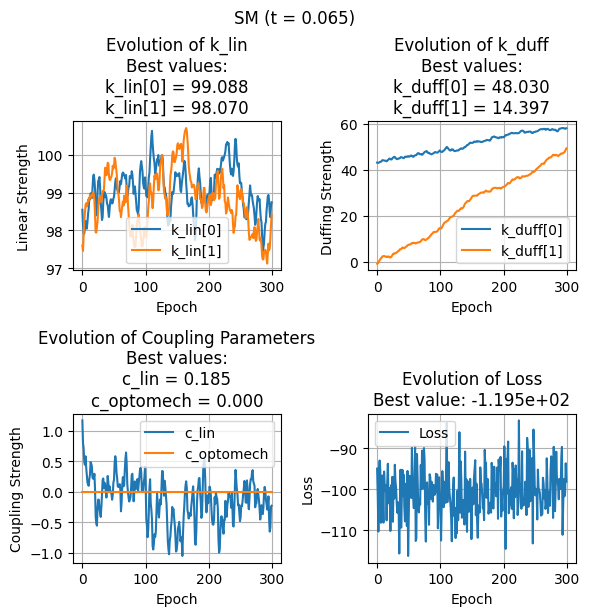

Optimization for time 0.06856782936641741 with num epochs: 3000
Epoch 0
params:
[99.18834172 98.16997629 48.12959595 14.29682947  0.28489044  0.        ]
Loss: -105.8350
---
Epoch 100
params:
[99.44169201 97.02677995 47.81625696 13.70874734 -0.31369203  0.        ]
Loss: -110.1712
---
Epoch 200
params:
[100.17960354  98.72117367  47.37908958  14.68748331  -0.49597769
   0.        ]
Loss: -107.4887
---
Epoch 300
params:
[101.13761982  99.80712289  46.90967986  15.46509122  -0.34638872
   0.        ]
Loss: -114.8306
---
Epoch 400
params:
[100.50969079  98.53910177  44.95859623  15.58258124  -0.29413525
   0.        ]
Loss: -91.2102
---
Epoch 500
params:
[100.19631404  98.1483418   42.7062631   15.26282378  -0.28251802
   0.        ]
Loss: -110.2832
---
Epoch 600
params:
[9.98996848e+01 9.78681831e+01 4.25966592e+01 1.46145286e+01
 3.86535481e-02 0.00000000e+00]
Loss: -98.1992
---
Epoch 700
params:
[100.30331124  98.58085388  41.35674256  14.94587093  -0.23374009
   0.        ]
Loss: -100

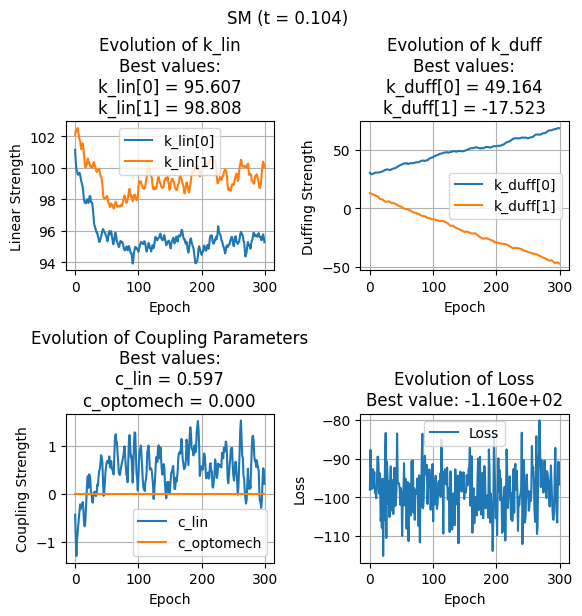

Optimization for time 0.1088401916069006 with num epochs: 3000
Epoch 0
params:
[ 95.70681218  98.90786547  49.26432185 -17.42308449   0.69728586
   0.        ]
Loss: -113.1139
---
Epoch 100
params:
[ 9.88670942e+01  9.98705966e+01  5.04091539e+01 -1.63981399e+01
  5.36598821e-02  0.00000000e+00]
Loss: -98.1770
---
Epoch 200
params:
[ 99.68661279 100.74213714  49.41063331 -15.85765582  -0.33908572
   0.        ]
Loss: -93.6555
---
Epoch 300
params:
[101.29586708 101.30800976  49.41214717 -15.12762776  -0.1994495
   0.        ]
Loss: -108.8893
---
Epoch 400
params:
[100.85257457 101.41382258  48.45989074 -14.50552464  -0.50883606
   0.        ]
Loss: -92.3965
---
Epoch 500
params:
[101.45970151 101.77737359  46.92445847 -15.21714984  -0.28151472
   0.        ]
Loss: -102.8378
---
Epoch 600
params:
[ 1.00944481e+02  1.01225652e+02  4.63821930e+01 -1.57048502e+01
 -8.82272140e-02  0.00000000e+00]
Loss: -95.3488
---
Epoch 700
params:
[ 1.01482339e+02  1.02147312e+02  4.64566687e+01 -1.44943

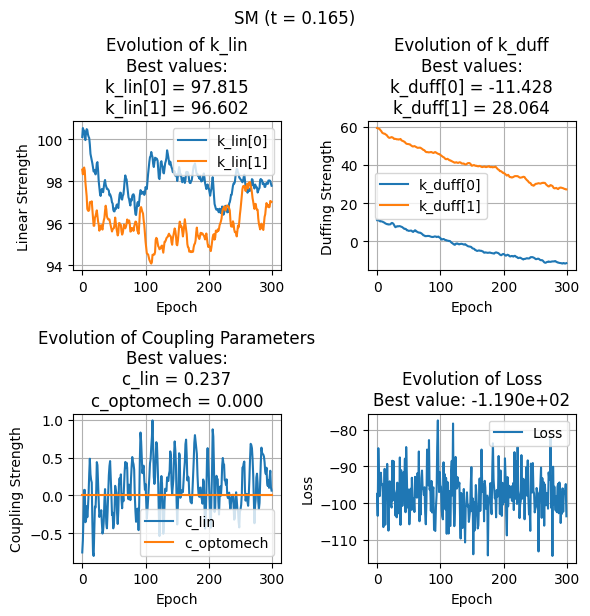

Optimization for time 0.17276596646690354 with num epochs: 3000
Epoch 0
params:
[ 97.91474249  96.70181984 -11.32796237  28.16406067   0.13682082
   0.        ]
Loss: -105.2649
---
Epoch 100
params:
[ 99.70899426  98.42399014 -10.30730203  28.23168373   0.39272193
   0.        ]
Loss: -105.9827
---
Epoch 200
params:
[100.3025007   97.90614347 -11.5638776   28.43941219  -0.31877511
   0.        ]
Loss: -109.6643
---
Epoch 300
params:
[101.38011678  99.12234966 -13.26887966  29.69489059  -0.32551798
   0.        ]
Loss: -100.4440
---
Epoch 400
params:
[100.68826638 100.27322565 -15.57992815  29.80609407  -0.42044864
   0.        ]
Loss: -106.1789
---
Epoch 500
params:
[101.62201087  99.16100665 -16.93557897  29.67061275  -0.4808519
   0.        ]
Loss: -99.6463
---
Epoch 600
params:
[102.02160228  98.77224421 -18.97997466  29.61044925  -0.6383826
   0.        ]
Loss: -95.1281
---
Epoch 700
params:
[101.10672463  99.42442774 -21.02706085  28.90479406  -0.62369457
   0.        ]
Loss: -84.

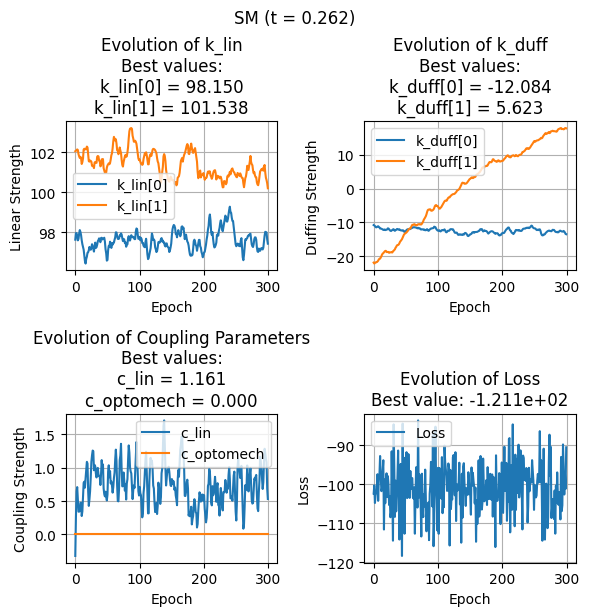

Optimization for time 0.2742376573264949 with num epochs: 3000
Epoch 0
params:
[ 98.04970787 101.43842111 -12.18361432   5.52261602   1.06082502
   0.        ]
Loss: -98.4862
---
Epoch 100
params:
[ 99.69081532 102.29491558  -9.87040667   6.57863723  -0.24431312
   0.        ]
Loss: -108.0552
---
Epoch 200
params:
[101.45732847 101.53095193  -8.7645332    6.95117275  -0.16868522
   0.        ]
Loss: -88.5059
---
Epoch 300
params:
[102.13686718 101.19421422  -8.56452479   7.85320322  -0.39340185
   0.        ]
Loss: -90.6549
---
Epoch 400
params:
[101.21287791 101.34624348  -8.03704083   8.87728042  -0.93517177
   0.        ]
Loss: -99.2385
---
Epoch 500
params:
[102.36375097 101.45551956  -7.65405304   9.24039992  -0.82441758
   0.        ]
Loss: -104.2465
---
Epoch 600
params:
[100.57757086 101.3948192   -8.53995307  10.12376497  -0.67736083
   0.        ]
Loss: -97.0431
---
Epoch 700
params:
[100.94415909 101.6654352   -7.37659336  11.17287165  -0.2886417
   0.        ]
Loss: -90.898

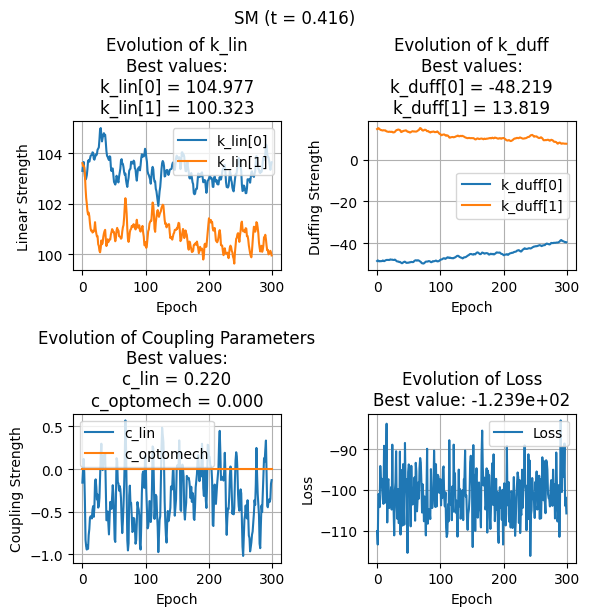

Optimization for time 0.43530733647318887 with num epochs: 3000
Epoch 0
params:
[104.87699205 100.22269873 -48.31943682  13.71940106   0.11996605
   0.        ]
Loss: -95.2591
---
Epoch 100
params:
[103.45042273  99.50013155 -48.79354512  13.48010411  -0.55902263
   0.        ]
Loss: -105.2275
---
Epoch 200
params:
[102.5984181   98.99727275 -49.9634677   12.51826897  -0.22566836
   0.        ]
Loss: -105.1006
---
Epoch 300
params:
[101.9161928   98.77988447 -50.41305817  12.19382696  -0.13419955
   0.        ]
Loss: -102.9483
---
Epoch 400
params:
[102.36360005  98.97466591 -50.59170167  11.68644434  -0.31845486
   0.        ]
Loss: -98.9955
---
Epoch 500
params:
[102.36660415  98.7058279  -50.02488581   9.67499534   0.35937661
   0.        ]
Loss: -89.0580
---
Epoch 600
params:
[ 1.01254508e+02  9.96686567e+01 -5.25165430e+01  9.95576170e+00
  2.53852061e-02  0.00000000e+00]
Loss: -106.3264
---
Epoch 700
params:
[102.50335795  98.96036409 -53.37382189   7.87314773  -0.18312299
   0. 

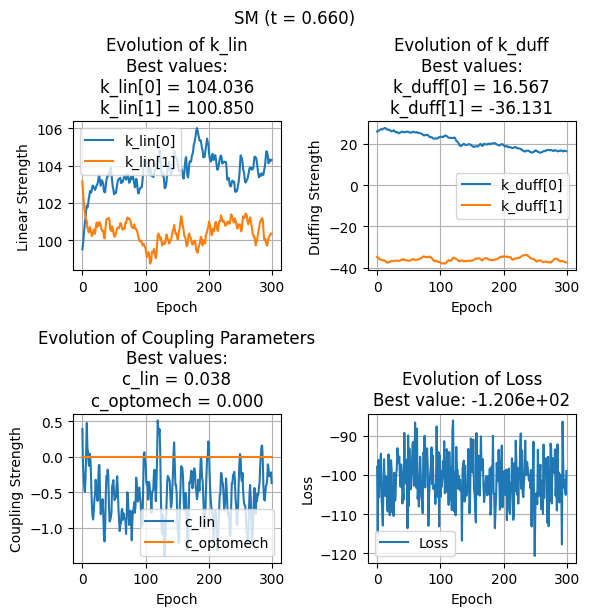

Optimization for time 0.6909790545715642 with num epochs: 3000
Epoch 0
params:
[103.93566539 100.950371    16.66666392 -36.03060848   0.13847532
   0.        ]
Loss: -103.9249
---
Epoch 100
params:
[101.65821047 100.90082459  15.56380935 -34.72538885   0.35845422
   0.        ]
Loss: -110.8619
---
Epoch 200
params:
[100.37757443 100.05322322  15.54832915 -33.81615266   0.6229322
   0.        ]
Loss: -93.1994
---
Epoch 300
params:
[ 98.25099453 100.35285559  14.70087458 -32.46528673   0.2996917
   0.        ]
Loss: -100.3341
---
Epoch 400
params:
[ 97.69522421 100.16396426  15.60528264 -29.64365076   0.16981685
   0.        ]
Loss: -91.1528
---
Epoch 500
params:
[ 97.89929921  99.8435134   17.14650833 -27.79948465   1.44091665
   0.        ]
Loss: -110.8979
---
Epoch 600
params:
[ 97.72071808  98.54467956  17.45473135 -26.96277979   0.53740713
   0.        ]
Loss: -81.4333
---
Epoch 700
params:
[ 98.31061781  99.80495039  18.34700762 -24.12918868   1.17090076
   0.        ]
Loss: -96.51

In [13]:
load_param_histories = False
filename = f"out/MNIST/{training_method}/params_history_means_{means.flatten()}_covs_{covs.flatten()}_weights_{weights}_t_forward_{t_forward}_n_timestes_{n_time_steps}.npy"
if load_param_histories:
    # Load existing parameters
    params_history_all_t = jnp.load(filename)
else:
    # Setup optimization parameters
    mask = jnp.ones(flattened_args_initial.shape[0])
    # mask = mask.at[0].set(1.)
    # mask = mask.at[1].set(1.)
    mask = mask.at[-1].set(0.0)
    learning_rate = 0.1
    n_epochs_start = 100000//2
    n_epochs_after_start = 3000
    batch_size = 2*128

    # Plotting parameters
    plot_steps = True  # Flag to control whether to plot during optimization
    plot_slice = 10     # Plot every nth step


    # Initialize storage for parameters at each time step
    params_history_all_t = []
    current_params = flattened_args_initial

    # Loop over time points
    for t_idx, t_forward in enumerate(forward_time_pts):
        print
        if t_idx == 0: 
            n_epochs = n_epochs_start
        else:
            n_epochs = n_epochs_after_start
        print(f"Optimization for time {t_forward} with num epochs: {n_epochs}")
        
        # Generate samples at current time
        key, subkey = jr.split(key)
        samples_t = sample_forward_process(
            t_forward, n_samples, D=1, sigma_final=sigma_final, samples0=samples_0, key=subkey
        )
        
        # Perform optimization starting from previous best parameters
        key, subkey = jr.split(key)
        
        params_history, loss_history = run_optimization(
            loss_fn_per_batch=loss_fn_per_batch,
            params_initial=current_params,
            samples=samples_t,
            mask=mask,
            gradient_fn_per_batch=gradient_fn_per_batch,
            key=subkey,
            batch_size=batch_size,
            learning_rate=learning_rate,
            n_epochs=n_epochs,
            maximize=maximize
        )
        
        _, best_params, _ = get_best_params(params_history, loss_history, maximize=maximize)
        k_lin_best, k_duff_best, c_lin_best, c_optomech_best = unflatten(best_params)
        current_params, _ = flatten_util.ravel_pytree(best_params)
        params_history_all_t.append(current_params)
        
        if plot_steps:
            if t_idx % plot_slice == 0:
                # Plot optimization progress
                plot_parameter_evolution(
                    params_history=params_history,
                    loss_history=loss_history,
                    unflatten=unflatten,
                    N_osc=N_osc,
                    slicing=10,
                    title=f"{training_method} (t = {t_forward:.3f})",
                    maximize=maximize
                )
                # Plot current energy landscape
                # plot_energy_and_distributions(
                #     energy_fn=energy_fn,
                #     param_list=[current_params],
                #     samples=samples_t,
                #     x1_range=(-1, 1),
                #     x2_range=(-1, 1),
                #     n_points=30,
                #     titles=[f"t = {t_forward:.3f}"],
                #     fontsize=16,
                #     sample_stride=1,
                #     suptitle=f"Energy Landscape at t = {t_forward:.3f}"
                # )
            
    # Convert params_history_all_t to array for easier analysis
    params_history_all_t = jnp.array(params_history_all_t)
    jnp.save(filename, params_history_all_t)


### Smoothen and interpolate parameter evolution

In [14]:
def smooth_parameters(params, window_lengths = [31, 31, 31, 31, 31, 31], poly_orders = [3, 3, 3, 3, 3, 3]):
    """
    Smooths multiple parameter trajectories using Savitzky-Golay filter
    
    Args:
        params: Array of shape (n_timesteps, n_params) containing parameter trajectories
        window_lengths: List/array of window lengths for each parameter dimension
        poly_orders: List/array of polynomial orders for each parameter dimension
    
    Returns:
        Array of shape (n_timesteps, n_params) containing smoothed parameter trajectories
    """
    n_params = params.shape[1]
    smoothed = []
    
    for i in range(n_params):
        # Ensure window length is odd and valid
        window_length = min(window_lengths[i], len(params) - (1 - len(params) % 2))
        if window_length % 2 == 0:
            window_length -= 1
            
        # Smooth using Savitzky-Golay filter
        smoothed.append(savgol_filter(params[:, i], window_length, poly_orders[i]))
    
    return jnp.column_stack(smoothed)


def interpolate_parameters(params, time_points):
    """
    Interpolates parameter trajectories using jnp.interp in a vectorized fashion.

    Args:
        params: Array of shape (n_timesteps, n_params) containing parameter trajectories.
        time_points: 1D array of shape (n_timesteps,) corresponding to the time points.

    Returns:
        A function that takes time points `t` (scalar or 1D array) and returns
        the interpolated parameters. For scalar `t`, the result is shape (n_params,);
        for vector `t`, the result is shape (len(t), n_params).
    """
    
    def _interpolator(t):
        # Transpose params to shape (n_params, n_timesteps) so that each row is a trajectory.
        # Use vmap to apply jnp.interp over each parameter trajectory.
        interpolated = jax.vmap(lambda param: jnp.interp(t, time_points, param))(params.T)
        # If t is an array, jnp.interp returns an array for each parameter, resulting in a
        # (n_params, len(t)) array. Transpose it so that each row corresponds to a time point.
        if jnp.ndim(t) > 0:
            return interpolated.T
        return interpolated

    return _interpolator


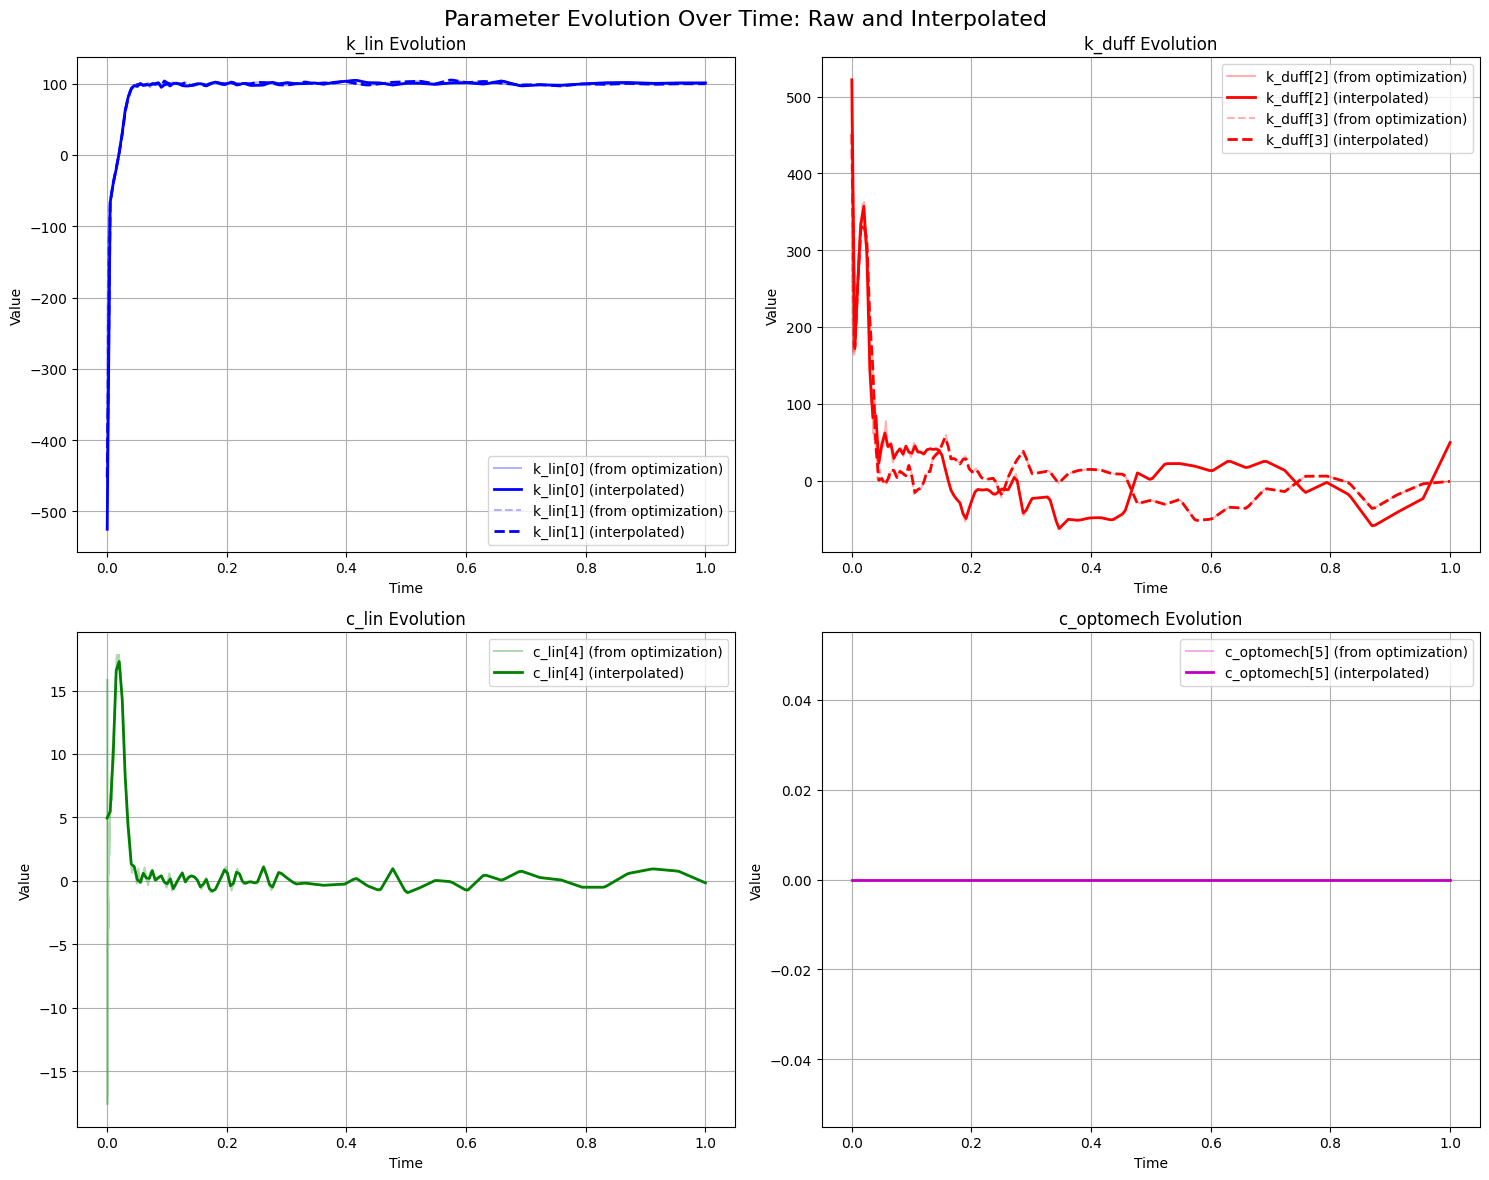

In [15]:
use_smoothed_params = False
if use_smoothed_params:
    # First smooth the parameters
    smoothed_params = smooth_parameters(params_history_all_t)
    # Get interpolator function
    params_interpolator = interpolate_parameters(smoothed_params, forward_time_pts)
else:
    # Get interpolator function
    params_interpolator = interpolate_parameters(params_history_all_t, forward_time_pts)

# Then interpolate the smoothed parameters
time_eval = jnp.linspace(forward_time_pts[0],forward_time_pts[-1],200)
# interpolated_params = interpolate_parameters(smoothed_params, forward_time_pts, time_dense)
interpolated_params = params_interpolator(time_eval)

# Create figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Evolution Over Time: Raw and Interpolated', fontsize=16)

# Plot settings
param_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech']
axes = [ax1, ax2, ax3, ax4]
colors = ['b', 'r', 'g', 'm']
param_indices = [(0,1), (2,3), (4,), (5,)]

# Plot for each parameter type
for ax, param_name, color, indices in zip(axes, param_names, colors, param_indices):
    for idx, style in zip(indices, ['-', '--']):
        # Plot raw data
        ax.plot(forward_time_pts, params_history_all_t[:, idx], color + style, alpha=0.3, 
                label=f'{param_name}[{idx}] (from optimization)')
        
        # Plot interpolated data
        ax.plot(time_eval, interpolated_params[:, idx], color + style, linewidth=2,
                label=f'{param_name}[{idx}] (interpolated)')
    
    ax.set_title(f'{param_name} Evolution')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

### Run reverse SDE:

In [16]:
forward_params = jnp.zeros_like(flattened_args_initial)
forward_params = forward_params.at[0].set(1.)
forward_params = forward_params.at[1].set(1.)
params_interpolator_reverse_plus_linear = lambda t: 2*params_interpolator(t_forward - t) - 1/sigma_final**2 * forward_params

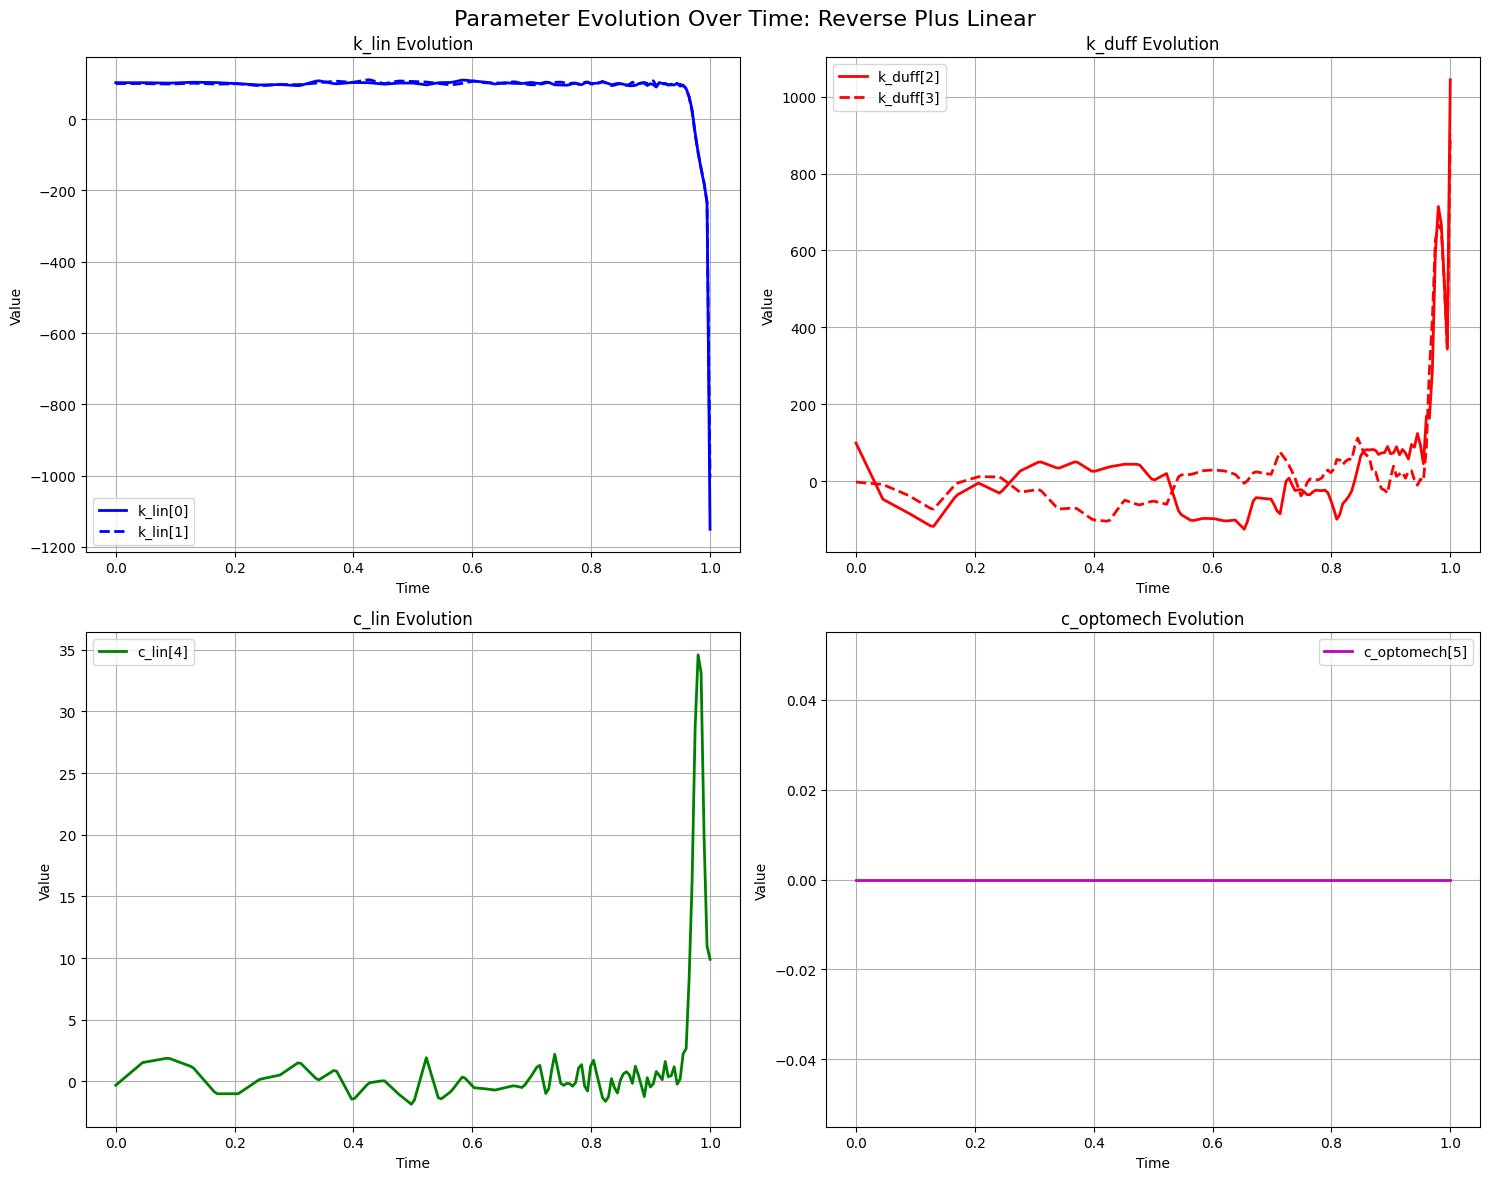

In [17]:
# Create time points for evaluation
time_eval = jnp.linspace(0, t_forward, 200)

# Get parameters at each time point
params_over_time = jnp.vstack([params_interpolator_reverse_plus_linear(t) for t in time_eval])

# Create figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Evolution Over Time: Reverse Plus Linear', fontsize=16)

# Plot settings
param_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech']
axes = [ax1, ax2, ax3, ax4]
colors = ['b', 'r', 'g', 'm']
param_indices = [(0,1), (2,3), (4,), (5,)]

# Plot for each parameter type
for ax, param_name, color, indices in zip(axes, param_names, colors, param_indices):
    for idx, style in zip(indices, ['-', '--']):
        ax.plot(time_eval, params_over_time[:, idx], color + style, linewidth=2,
                label=f'{param_name}[{idx}]')
    
    ax.set_title(f'{param_name} Evolution')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [18]:
# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse_plus_linear, N_osc, time_dependent_parms=True)

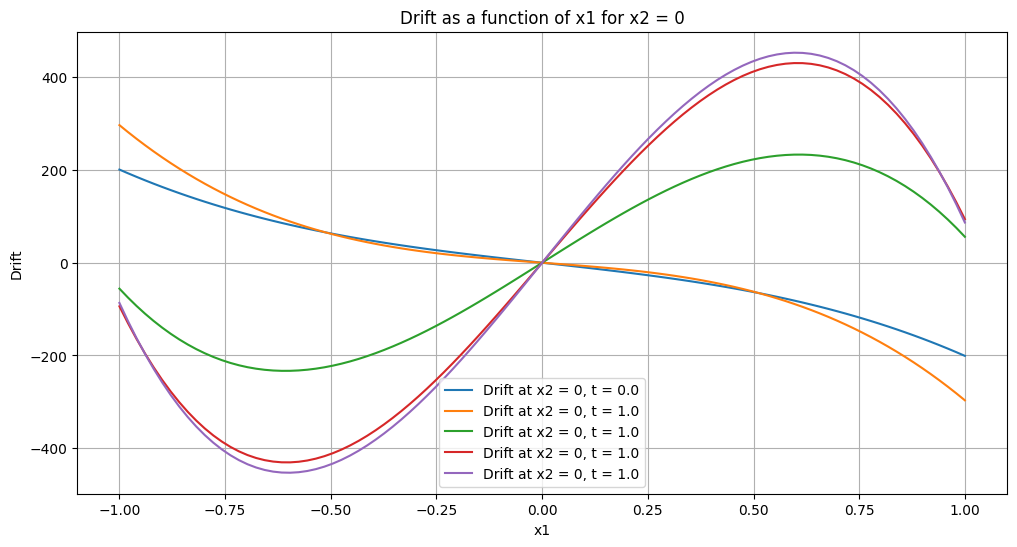

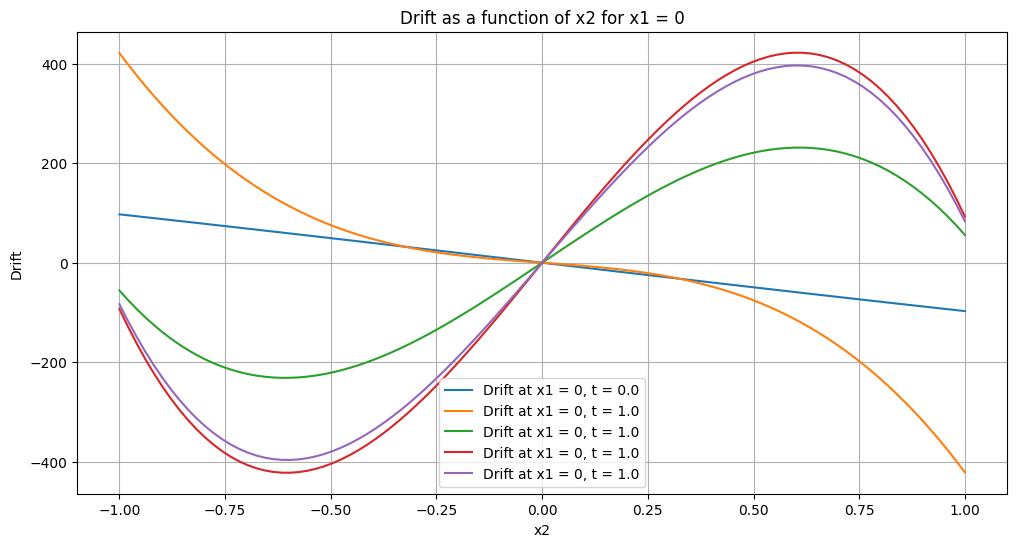

In [19]:
# Assuming drift_fn is already defined and takes (time, state, args) as input
# Define the range for x1 and x2
x_range = jnp.linspace(-1, 1, 100)  # Example range from -5 to 5

# Define filename for saving/loading parameters
n_time_steps = 5
# forward_time_pts = jnp.linspace(0., t_forward, n_time_steps)
time_steps = t_forward - jnp.exp(jnp.linspace(jnp.log(t_forward), jnp.log(1e-6), n_time_steps))


# Plot drift as a function of x1 for x2 = 0
plt.figure(figsize=(12, 6))
for t in time_steps:
    drift_x1 = [drift_fn(t, jnp.array([x1, 0]), args=())[0] for x1 in x_range]
    plt.plot(x_range, drift_x1, label=f'Drift at x2 = 0, t = {t:.1f}')

plt.xlabel('x1')
plt.ylabel('Drift')
plt.title('Drift as a function of x1 for x2 = 0')
plt.legend()
plt.grid(True)
plt.show()

# Plot drift as a function of x2 for x1 = 0
plt.figure(figsize=(12, 6))
for t in time_steps:
    drift_x2 = [drift_fn(t, jnp.array([0, x2]), args=())[1] for x2 in x_range]
    plt.plot(x_range, drift_x2, label=f'Drift at x1 = 0, t = {t:.1f}')

plt.xlabel('x2')
plt.ylabel('Drift')
plt.title('Drift as a function of x2 for x1 = 0')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
t0 = 0.0
t1 = t_forward
ts = jnp.linspace(t0, t1, 10)
dt0 = ts[1] - ts[0]

# Generate multiple initial states
# n_trajectories = 2000
# key, subkey = jr.split(key)
# initial_states = sample_forward_process(t_forward, n_trajectories, D=1, samples0=samples_0, key=subkey, diffusion_rate=diffusion_rate)
# Sample initial conditions from N(0, I)
n_trajectories = 1000  # or any other number of trajectories you need
n_dimensions = 2  # assuming 2D, adjust as necessary
key, subkey = jr.split(key)
initial_states = jr.normal(subkey, (n_trajectories, n_dimensions))

# Generate a key for each initial condition
key, subkey = jr.split(key)
keys_brownian = jr.split(subkey, n_trajectories)

# Vectorize solve_SDE across both initial states and keys
vectorized_solve_SDE = vmap(
    lambda init_state, key_b: solve_SDE(
        drift_fn, 
        diffusion_fn, 
        init_state,
        key_b, 
        t0, 
        t1, 
        ts.shape[0], 
        dt0
    ),
    in_axes=(0, 0)
)


# Run SDE for all initial states at once
solutions = vectorized_solve_SDE(initial_states, keys_brownian)
all_trajectories = solutions.ys  # Shape: (n_trajectories, n_timesteps, 2)
final_states = all_trajectories[:, -1, :]  # Shape: (n_trajectories, 2)


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

In [21]:
solve_time = 0.0
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator(solve_time), N_osc,time_dependent_parms=False)
t0 = 0.0
t1 = 10 
ts = jnp.linspace(t0, t1, 1000)
dt0 = ts[1] - ts[0]
initial_state = jnp.array([-.5,0.])
key_equilibrium = jr.PRNGKey(111111)
solution_direct = solve_SDE(drift_fn, diffusion_fn, initial_state,key_equilibrium, t0, t1, ts.shape[0], dt0)
sde_samples_direct = solution_direct.ys


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

Solution from reverse process probability distribution total (should be ≈ 1): 1.000000


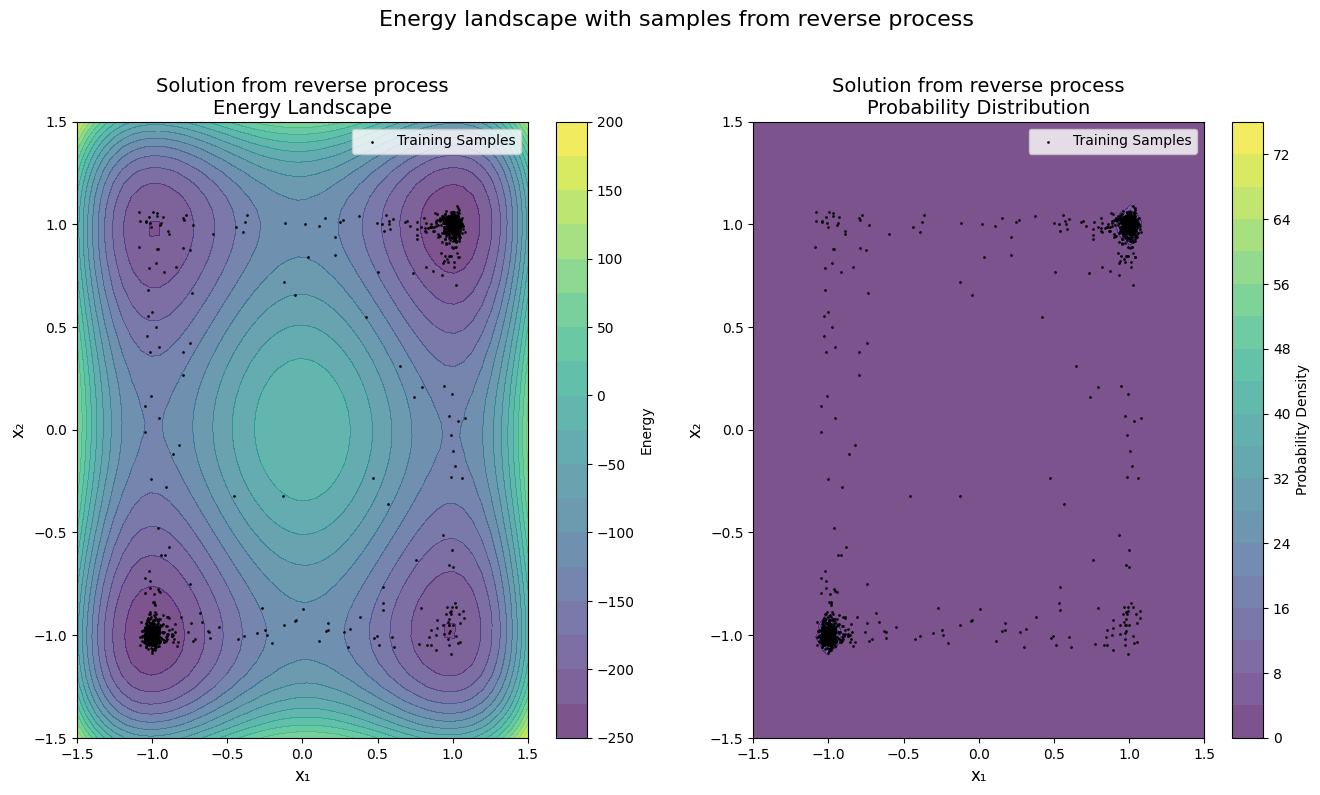

In [22]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from reverse process"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=final_states,
    sample_stride=1,
    x1_range=(-1.5, 1.5),    
    x2_range=(-1.5, 1.5),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from reverse process"  
)

Solution from direct integration probability distribution total (should be ≈ 1): 1.000000


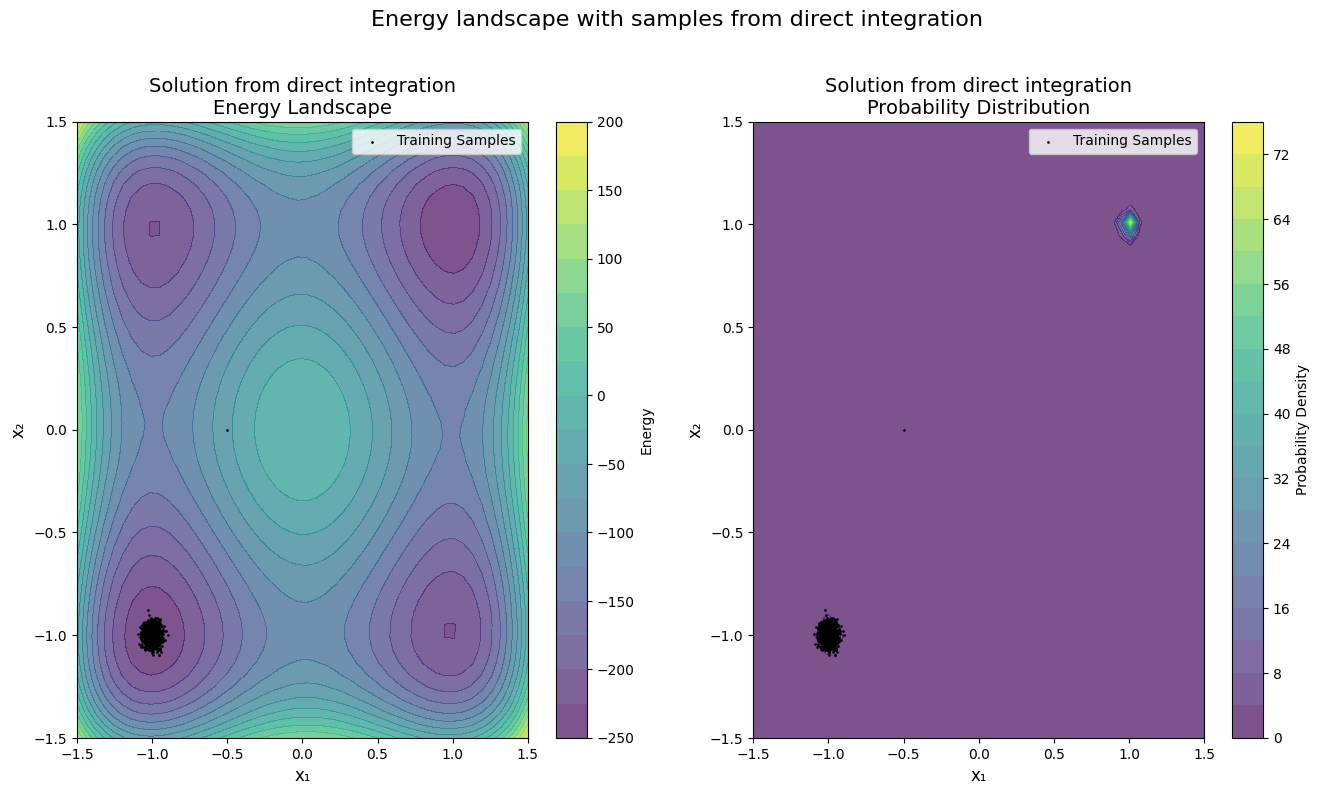

In [23]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from direct integration"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=sde_samples_direct,
    sample_stride=1,
    x1_range=(-1.5, 1.5),    
    x2_range=(-1.5, 1.5),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from direct integration"  
)

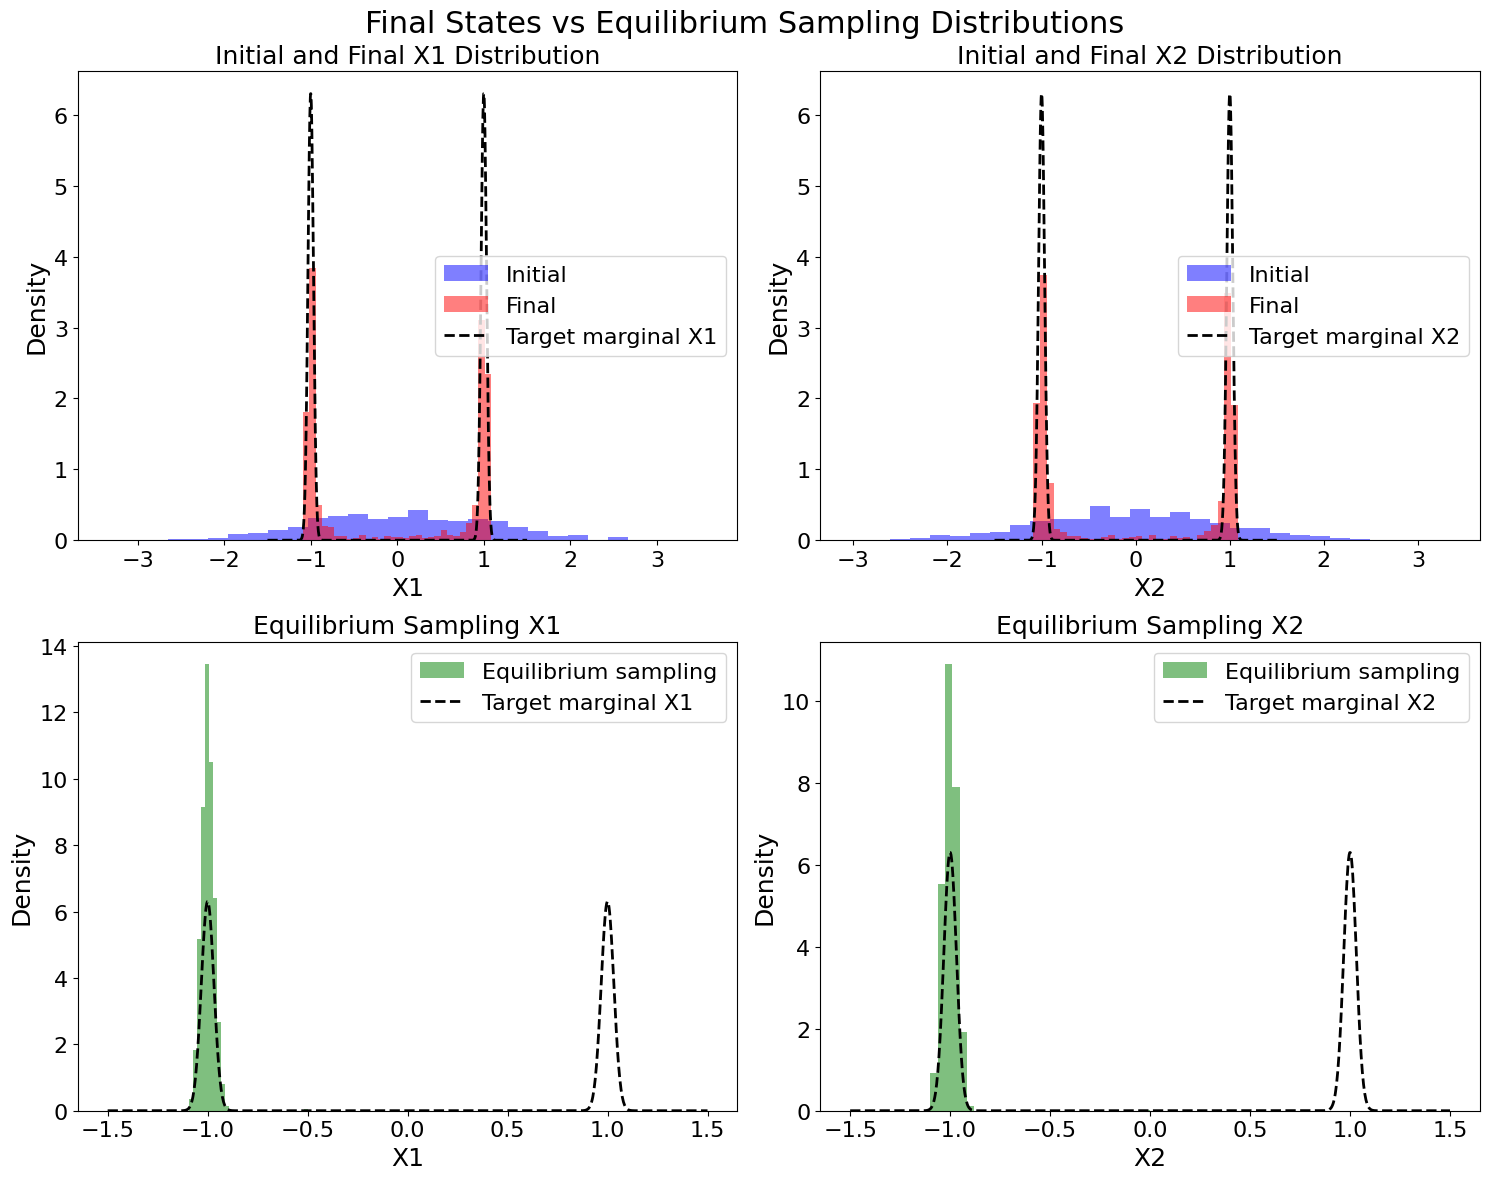

In [24]:
# Set font sizes
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 22

# Create 2x2 subplot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Final States vs Equilibrium Sampling Distributions', fontsize=BIGGER_SIZE)

# Top row: Initial and Final states
ax1.hist(initial_states[:, 0], bins=30, alpha=0.5, density=True, label='Initial', color='blue')
ax1.hist(final_states[:, 0], bins=30, alpha=0.5, density=True, label='Final', color='red')
ax2.hist(initial_states[:, 1], bins=30, alpha=0.5, density=True, label='Initial', color='blue')
ax2.hist(final_states[:, 1], bins=30, alpha=0.5, density=True, label='Final', color='red')

# Bottom row: Equilibrium sampling in green
ax3.hist(sde_samples_direct[:, 0], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')
ax4.hist(sde_samples_direct[:, 1], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')

# Add exact marginal Gaussians to all plots
x = jnp.linspace(-1.5, 1.5, 1000)

# Plot marginals for each subplot separately with correct dimension
for ax, dim in [(ax1, 0), (ax2, 1), (ax3, 0), (ax4, 1)]:
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax.plot(x, marginal, '--k', linewidth=2, label=f'Target marginal {["X1", "X2"][dim]}')
    
    # Increase font sizes for tick labels
    ax.tick_params(axis='both', which='major', labelsize=SMALL_SIZE)

# Set titles and labels with increased font sizes
ax1.set_title('Initial and Final X1 Distribution', fontsize=MEDIUM_SIZE)
ax1.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax1.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax1.legend(fontsize=SMALL_SIZE)

ax2.set_title('Initial and Final X2 Distribution', fontsize=MEDIUM_SIZE)
ax2.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax2.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax2.legend(fontsize=SMALL_SIZE)

ax3.set_title('Equilibrium Sampling X1', fontsize=MEDIUM_SIZE)
ax3.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax3.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax3.legend(fontsize=SMALL_SIZE)

ax4.set_title('Equilibrium Sampling X2', fontsize=MEDIUM_SIZE)
ax4.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax4.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax4.legend(fontsize=SMALL_SIZE)

plt.tight_layout()
plt.show()